# Maize Leaf Disease Classification

## Problem Statement

Maize foliar diseases - **Common Rust**, **Gray Leaf Spot** and **Blight** - spread rapidly and can cut yields by 30-50%. The current diagnosis method is visual inspection by a human agronomist: slow, subjective, error-prone, and impossible to scale across large plantations. Many smallholder farmers have no access to a plant pathologist, so disease is caught only after irreversible damage.

**Objective:** classify a maize leaf image into one of four classes - *Healthy, Common Rust, Gray Leaf Spot, Blight* - so a farmer can photograph a leaf and get an instant diagnosis.

**Research questions:**

1. How accurately can a pretrained YOLO26 classifier separate these four classes, and how much of that is thanks to transfer learning rather than training from scratch?
2. How close does a small custom CNN trained from scratch get, and is it small and fast enough to be worth deploying instead?
3. Which classes get confused with each other, and why - background clutter, lighting, or the visual overlap between Blight and Gray Leaf Spot?
4. How do model size, augmentation and training time trade off against accuracy on a dataset this small?

## Project Overview

A supervised image-classification pipeline with **two models** and a head-to-head comparison:

```
Data -> Validation + Deduplication -> 70/15/15 Split -> Training classes levelled
     -> Model A: YOLO26n-cls (transfer learning)  --\
     -> Model B: Custom CNN (Keras, from scratch) --> Comparison -> best model
     -> Inference -> Error Analysis -> Explainability -> Error Reduction -> Export
```

This is a **classification** problem, not a detection one. The dataset gives one label per photo and contains no bounding boxes, so the model is asked *what disease is this* rather than *where on the leaf is the lesion*.

| | Model A | Model B |
|---|---|---|
| Model | `yolo26n-cls.pt` | custom CNN, 2 conv/pool blocks |
| Starting weights | ImageNet-pretrained | random |
| Framework | PyTorch (ultralytics) | TensorFlow / Keras |
| Why it is here | the accuracy benchmark | shows what transfer learning is actually worth |

**What each split is for, and the rules the notebook follows:**

- **train** - what both models learn from. Class imbalance is fixed here, once, by levelling it to the largest class.
- **val** - the only split any *decision* is made on: model choice in 5.7, every experiment in 7.4, error analysis in section 6.
- **test** - scored once, in 9.3, with the final model. Never selected on, never tuned on.

- **Hardware:** Apple M4 GPU (MPS) for Model A. TensorFlow does not use MPS on macOS, so Model B trains on the CPU - a large part of why it is slower.
- **How Model A stays fast:**
  - `imgsz=256` instead of the usual 640 - 3,852 of the 4,186 images are already exactly 256x256, so a bigger size would only waste time.
  - `batch=64` on the GPU, so each epoch takes fewer, bigger steps.
  - No RAM image cache - it was measured to be *slower* here (54s vs 28s for one epoch), so it is left off.
- **Expected runtime:** a few minutes for sections 0-6, plus roughly 10 to 15 minutes for the retraining experiments in section 7.

## Dataset Overview

**Source:** [Kaggle - Corn or Maize Leaf Disease Dataset](https://www.kaggle.com/datasets/smaranjitghose/corn-or-maize-leaf-disease-dataset)

| Class | Images | Share |
|---|---|---|
| Common_Rust | 1,306 | 31.2% |
| Healthy | 1,162 | 27.8% |
| Blight | 1,146 | 27.4% |
| Gray_Leaf_Spot | 572 | 13.7% |
| **Total** | **4,186** | **100%** |

Real-world leaf photographs stored as `data/<Class_Name>/*.jpg`, where the folder name *is* the label - so a photo dropped into a class folder is picked up automatically. Section 1.2 indexes the files by content hash, so 2 byte-identical duplicates carrying different labels are dropped before anything else runs.

The split is **70 / 15 / 15**. Before levelling, that is 2,936 train / 625 val / 625 test. Section 2.1 then repeats the training split up to 916 images per class, giving a **3,664**-image training set.

- **train** - what both models learn from. 916 per class after levelling.
- **val** - 625 images, natural distribution. Every model-selection decision in the notebook is made here.
- **test** - 625 images, natural distribution. Sections 3.8 and 4.10 score it once each so the section 5 comparison has a like-for-like figure, and 9.3 scores the final model on it. No model, epoch, recipe or threshold is ever chosen using those numbers.

The dataset is imbalanced: Gray Leaf Spot has 2.3x fewer images than Common Rust, and it is also the class the model struggles with most. Levelling the *training* split does not create new photographs of Gray Leaf Spot, so the class stays the hardest one. Section 10 is explicit about what that means for the limits of the result.

**Known issues in the raw data:**

- Mixed file extensions (`.jpg`, `.JPG`, `.jpeg`). Several hundred files end in uppercase `.JPG`, which a lowercase `*.jpg` glob silently misses.
- Mixed colour modes: 4 images are RGBA and 1 is CMYK.
- Resolutions from 180x116 up to 5184x5184, although 3,852 images are exactly 256x256.
- Non-uniform backgrounds and lighting.
- Label noise. Two photographs appear twice under two different class labels, and more may be near-duplicates or mislabelled where harmless blemishes resemble early-stage disease.

## Environment Setup & Configuration

### Import Libraries

In [1]:
import hashlib
import random
import shutil
import time
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from IPython.display import Image, display
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from ultralytics import YOLO

### Configuration

In [2]:
MODEL_NAME   = "models/yolo26n-cls.pt" 
EPOCHS      = 5  
IMGSZ       = 256                      
BATCH       = 64                       
DEVICE      = "mps"                    

VAL_FRACTION  = 0.15                   
TEST_FRACTION = 0.15                    
SEED        = 42                        

CNN_IMGSZ  = 128                        
CNN_EPOCHS = 20                        
CNN_BATCH  = 32
TARGET_ACCURACY = 0.96

MODELS_DIR  = Path("models")            
DATASET_DIR = Path("data_cls")          
REPORT_PATH = Path("model_comparison.md") 

print(f"Model A: {MODEL_NAME}  epochs={EPOCHS}  imgsz={IMGSZ}  batch={BATCH}  device={DEVICE}")
print(f"Model B: imgsz={CNN_IMGSZ}  epochs={CNN_EPOCHS}  batch={CNN_BATCH}")
print(f"Split:   70% train / {VAL_FRACTION:.0%} val / {TEST_FRACTION:.0%} test   seed={SEED}")

Model A: models/yolo26n-cls.pt  epochs=5  imgsz=256  batch=64  device=mps
Model B: imgsz=128  epochs=20  batch=32
Split:   70% train / 15% val / 15% test   seed=42


### Set Random Seeds

In [3]:
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. Data Preparation & Validation

### 1.1 Dataset Paths

The images are in four flat folders, one per class. Both models want the data inside a single dataset folder with one folder per split, so section 2 builds that structure.

In [4]:
SRC = Path("data")                      
CLASS_FOLDERS = ["Blight", "Common_Rust", "Gray_Leaf_Spot", "Healthy"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

for name in CLASS_FOLDERS:
    print(f"{name:16s} -> {SRC / name}")

Blight           -> data/Blight
Common_Rust      -> data/Common_Rust
Gray_Leaf_Spot   -> data/Gray_Leaf_Spot
Healthy          -> data/Healthy


### 1.2 Dataset Validation

Counts the images per class, opens each one to make sure nothing is broken, and drops any file that is a byte-for-byte copy of another. Class imbalance is dealt with in section 2, not here.

In [5]:
# Files are indexed by content hash so the same photo cannot enter the pipeline
# twice under two different names, or under two different class labels.
IMAGE_FILES = {}
seen_hashes = {}
duplicates = []
broken = []
total = 0

for name in CLASS_FOLDERS:
    folder = SRC / name
    candidates = sorted(p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTS)

    unique = []
    for image in candidates:
        if cv2.imread(str(image)) is None:
            broken.append(image)
            continue

        digest = hashlib.md5(image.read_bytes()).hexdigest()
        if digest in seen_hashes:
            duplicates.append((image, seen_hashes[digest]))
            continue

        seen_hashes[digest] = image
        unique.append(image)

    IMAGE_FILES[name] = unique
    total += len(unique)
    print(f"{name:16s} {len(candidates):5d} files  ->  {len(unique):5d} unique")

print(f"\n{'TOTAL':16s} {total:5d} unique images")
print(f"Unreadable files: {len(broken)}")
print(f"Exact duplicates: {len(duplicates)}")

for dropped, kept in duplicates:
    print(f"  dropped {dropped}  (byte-identical to {kept.parent.name}/{kept.name})")

if duplicates:
    print("\nNote: these duplicates sat in two different class folders, so the same photo")
    print("carried two different disease labels. One of the two is simply wrong, and the")
    print("pair of classes involved is exactly the pair section 6 finds most confusable.")

Blight            1146 files  ->   1146 unique


Common_Rust       1306 files  ->   1306 unique


Gray_Leaf_Spot     574 files  ->    572 unique


Healthy           1162 files  ->   1162 unique

TOTAL             4186 unique images
Unreadable files: 0
Exact duplicates: 2
  dropped data/Gray_Leaf_Spot/Corn_Gray_Spot (19).jpg  (byte-identical to Blight/Corn_Blight (77).jpg)
  dropped data/Gray_Leaf_Spot/Corn_Gray_Spot (564).jpg  (byte-identical to Blight/Corn_Blight (1104).jpg)

Note: these duplicates sat in two different class folders, so the same photo
carried two different disease labels. One of the two is simply wrong, and the
pair of classes involved is exactly the pair section 6 finds most confusable.


- The scan uses `p.suffix.lower()`, so the uppercase `.JPG` files are counted too. A plain `*.jpg` glob would have silently dropped several hundred images.
- Deduplication is by file content, not by name. Two files with different names can be the same photo, and the 2.2 leak check keys on filenames, so it cannot catch this on its own.
- Both duplicates sat in two different class folders, meaning the same photograph carried two different disease labels. One of the two is simply wrong.
- 4,186 unique readable images means nothing needs cleaning beyond the duplicates, so the folder layout is otherwise trusted as-is.
- `IMAGE_FILES` is now the single source of truth for the dataset. Every later section reads from it rather than re-globbing the folders, so a dropped duplicate cannot reappear downstream.

### 1.3 Class Inspection

How many images each class has, which class index each model will give it, and one sample photo per class so you can eyeball the labels. Both models sort the class folders alphabetically, so both use the same index order.

In [6]:
CLASS_NAMES = sorted(CLASS_FOLDERS)   # YOLO and Keras both sort the class folders, so this IS the index order
counts = {name: len(IMAGE_FILES[name]) for name in CLASS_NAMES}

for index, name in enumerate(CLASS_NAMES):
    print(f"  {index}: {name:16s} {counts[name]:5d} images  ({counts[name] / total:.1%})")

  0: Blight            1146 images  (27.4%)
  1: Common_Rust       1306 images  (31.2%)
  2: Gray_Leaf_Spot     572 images  (13.7%)
  3: Healthy           1162 images  (27.8%)


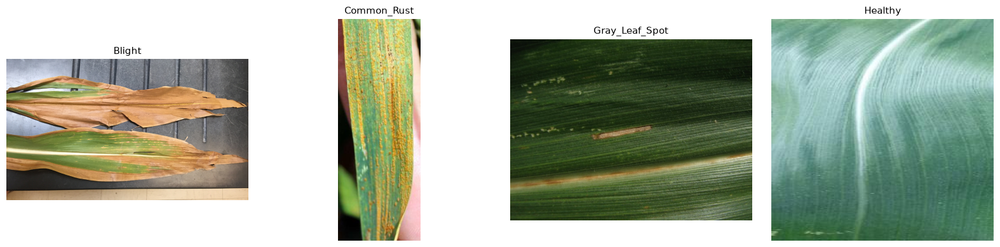

In [7]:
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(4 * len(CLASS_NAMES), 4))

for ax, name in zip(axes, CLASS_NAMES):
    sample = cv2.imread(str(sorted(IMAGE_FILES[name])[0]))
    ax.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
    ax.set_title(name, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

- One photo per class, so this is a sanity check that the folder-to-label mapping is right, not evidence about the data.
- The classes are told apart by lesion colour and shape, which is exactly what a classifier can latch onto.
- The backgrounds are messy field photos rather than clean studio shots, which is realistic for a farmer's phone and hard for a model.

### 1.4 Class Distribution Check

The dataset is not balanced. Gray Leaf Spot has roughly half the images of the other three classes.

In [8]:
largest_name = max(counts, key=counts.get)
smallest_name = min(counts, key=counts.get)

print(f"Largest class : {largest_name:16s} {counts[largest_name]:5d} images")
print(f"Smallest class: {smallest_name:16s} {counts[smallest_name]:5d} images")
print(f"Ratio         : {counts[largest_name] / counts[smallest_name]:.1f}x")
print()

for name in CLASS_NAMES:
    print(f"{name:16s} {counts[name]:5d} {counts[name] / total:6.1%}")

Largest class : Common_Rust       1306 images
Smallest class: Gray_Leaf_Spot     572 images
Ratio         : 2.3x

Blight            1146  27.4%
Common_Rust       1306  31.2%
Gray_Leaf_Spot     572  13.7%
Healthy           1162  27.8%


- Gray Leaf Spot has 572 images against 1,306 for Common Rust, so it is 2.3x smaller than the largest class. Every other class sits near 1,150.
- A class this much smaller gets seen far less often during training, which is why it is the hardest class to learn and the easiest one to miss in the field.
- Section 2.1 levels the training split up to the largest class so the two models are compared on equal footing. Validation and test are deliberately left alone.

## 2. Create Dataset Folder Structure

### 2.1 Generate Folder Structure, Split & Level the Training Classes

The split is 70 / 15 / 15 as before. The extra step is levelling the **training** split up to the largest class, so class imbalance is fixed once in the data pipeline instead of being treated as an error-reduction experiment later.

Only `train` is repeated. `val` and `test` keep the natural class distribution, because every score in this notebook is measured on those two splits and inflating them would make the numbers meaningless.

In [9]:
rng = random.Random(SEED)
shutil.rmtree(DATASET_DIR, ignore_errors=True)           # rebuilt from scratch every run

for split in ("train", "val", "test"):
    (DATASET_DIR / split).mkdir(parents=True, exist_ok=True)

for name in CLASS_FOLDERS:
    images = list(IMAGE_FILES[name])
    rng.shuffle(images)
    n_val = int(len(images) * VAL_FRACTION)
    n_test = int(len(images) * TEST_FRACTION)

    for split, batch in (
        ("test", images[:n_val]),
        ("val", images[n_val:n_val + n_test]),
        ("train", images[n_val + n_test:]),
    ):
        out = DATASET_DIR / split / name
        out.mkdir(parents=True, exist_ok=True)
        for image in batch:
            shutil.copy2(image, out / image.name)

# Class imbalance is handled here, once, for both models at the same time.
# Levelling the folder rather than passing class weights keeps the comparison
# fair: YOLO and Keras then train on exactly the same images.
train_counts = {name: len(list((DATASET_DIR / "train" / name).iterdir())) for name in CLASS_NAMES}
train_target = max(train_counts.values())

for name in CLASS_NAMES:
    out = DATASET_DIR / "train" / name
    if train_counts[name] >= train_target:
        continue

    originals = sorted(out.iterdir())
    index = 0
    while len(list(out.iterdir())) < train_target:
        source = originals[index % len(originals)]
        shutil.copy2(source, out / f"repeat_{index:04d}_{source.name}")
        index += 1

print(f"Training split levelled up to {train_target} images per class")
for name in CLASS_NAMES:
    before = train_counts[name]
    after = len(list((DATASET_DIR / "train" / name).iterdir()))
    print(f"  {name:16s} {before:5d} -> {after:5d}  ({after / before:.2f}x)")

Training split levelled up to 916 images per class
  Blight             804 ->   916  (1.14x)
  Common_Rust        916 ->   916  (1.00x)
  Gray_Leaf_Spot     402 ->   916  (2.28x)
  Healthy            814 ->   916  (1.13x)


### 2.2 Verify Split

Confirms every image landed in exactly one place, and that no photo appears in two splits - a duplicate there would quietly inflate every accuracy number in the notebook.

In [10]:
print(f"{'Class':16s} {'train':>6s} {'val':>5s} {'test':>5s}")
for name in CLASS_NAMES:
    n_train = len(list((DATASET_DIR / "train" / name).iterdir()))
    n_val = len(list((DATASET_DIR / "val" / name).iterdir()))
    n_test = len(list((DATASET_DIR / "test" / name).iterdir()))
    print(f"{name:16s} {n_train:6d} {n_val:5d} {n_test:5d}")

for split in ("train", "val", "test"):
    total_files = len([p for p in (DATASET_DIR / split).rglob("*") if p.is_file()])
    print(f"{split:16s} {total_files:6d} total")

# Leak check on the ORIGINAL photos. Two different kinds of collision are possible
# here and only one of them is a bug:
#
#   - the same photo in train AND val/test. That is a leak, and it would inflate
#     every score in this notebook.
#   - the same photo twice inside train. That is the levelling from 2.1 doing its
#     job, and it is expected.
#
# repeat_ copies are stripped back to their source name first, so an intentional
# repeat is recognised as a repeat rather than as a second, different image.
seen = {}
leaks = []
intentional_repeats = 0

for split in ("train", "val", "test"):
    for image in (DATASET_DIR / split).rglob("*"):
        if image.suffix.lower() not in IMAGE_EXTS:
            continue
        source_name = image.name.split("_", 2)[-1] if image.name.startswith("repeat_") else image.name
        key = f"{image.parent.name}/{source_name}"
        if key in seen:
            if seen[key] == split:
                intentional_repeats += 1
            else:
                leaks.append((key, seen[key], split))
        seen[key] = split

print(f"\nPhotos used in two different splits (leaks): {len(leaks)}")
for key, first, second in leaks[:10]:
    print(f"  {key}: {first} and {second}   <- LEAK")

print(f"Training repeats sharing a source inside train (expected): {intentional_repeats}")
assert not leaks, "the same photo is in two different splits"
print("No photo appears in two different splits.")

# No repeats may exist outside train, or the levelling would leak into scoring.
stray = [p for split in ("val", "test") for p in (DATASET_DIR / split).rglob("repeat_*")]
print(f"Repeated files found outside train: {len(stray)}")
assert not stray, "levelled copies leaked into val or test"

Class             train   val  test
Blight              916   171   171
Common_Rust         916   195   195
Gray_Leaf_Spot      916    85    85
Healthy             916   174   174
train              3664 total
val                 625 total
test                625 total



Photos used in two different splits (leaks): 0
Training repeats sharing a source inside train (expected): 728
No photo appears in two different splits.
Repeated files found outside train: 0


- Training rows now all read 916, because the smaller classes were repeated up to the largest. That is the imbalance fix, and it lives here rather than in section 7.
- Validation and test still show the natural distribution, 85 to 195 images per class. Those are the splits every score in this notebook is measured on, so repeating them would inflate every accuracy here.
- Two numbers come out of that check and only one of them is a problem. Photos found in **two different splits** must be zero, and the cell asserts it. Photos found **twice inside train** are the levelling repeats from 2.1, so that count is expected to be non-zero.
- `repeat_` files are stripped back to their source name before the check runs. Without that step an intentional repeat would be mistaken for a second, different photograph, and the check would report hundreds of phantom leaks.
- Repetition teaches the model how often a class occurs, not what a new case looks like. Gray Leaf Spot is still only 572 distinct photographs underneath.

## 3. Model A: YOLO26n-cls Pipeline

### 3.1 Load Pre-trained Classification Model

`yolo26n-cls.pt` is already trained on 1,000 ImageNet classes.

In [11]:
model_a = YOLO(MODEL_NAME)
model_a.info()

YOLO26n-cls summary: 120 layers, 2,812,104 parameters, 0 gradients, 3.3 GFLOPs


(120, 2812104, 0, 3.31530496)

**What transfer learning actually does here**

`yolo26n-cls.pt` was trained on ImageNet, a dataset of 1,000 unrelated classes. By the time it reaches this notebook it already knows general-purpose visual structure: edges and texture near the bottom of the network, then shapes and parts, then whole-object concepts. None of it is about maize, and all of it is reusable.

Ultralytics loads those weights and replaces the classification head. The shipped model ends in a 1,000-way softmax; this dataset has 4 classes, so the final layer is rebuilt at `nc=4` and re-initialised. That head is the only part that starts from scratch.

Fine-tuning then updates **every** parameter, not just the new head. `lr0=0.01` with weight decay 0.0005 nudges the pretrained filters rather than rewriting them, which is why five epochs is enough. Freezing the backbone instead would train faster but typically lands a few points lower on a dataset this small.

Two details worth knowing before reading the logs:

- The parameter count drops from 2,812,104 to 1,531,148 after fusion because the head shrinks from 1,000 classes to 4. The convolutional trunk, the part that carries the pretrained knowledge, is unchanged.
- `Overriding model.yaml nc=1000 with nc=4` in the training log is that head replacement, and nothing else.

The practical consequence for the comparison: Model A is not "a small model versus a small model". It is a 2.8M-parameter network that skipped the part of training where a network works out what an edge is. Model B in section 4 has to learn all of that from 3,664 photographs. That difference is what section 5 measures.

### 3.2 Configure Training Arguments

These are the arguments. The four marked `SPEED` are the ones that decide how long this takes.

In [12]:
train_args = dict(
    data=str(DATASET_DIR), 
    epochs=EPOCHS,     
    imgsz=IMGSZ,           
    batch=BATCH,           
    device=DEVICE,    
    workers=8,
    seed=SEED,
    name="model_a_yolo26n",
    exist_ok=True,
    plots=True,    
)

for key, value in train_args.items():
    print(f"{key:12s} = {value}")

data         = data_cls
epochs       = 5
imgsz        = 256
batch        = 64
device       = mps
workers      = 8
seed         = 42
name         = model_a_yolo26n
exist_ok     = True
plots        = True


### 3.3 Start Training

In [13]:
start = time.time()
model_a.train(**train_args)
yolo_train_seconds = time.time() - start

print(f"Training finished in {yolo_train_seconds:.0f} seconds ({yolo_train_seconds / 60:.1f} minutes)")

New https://pypi.org/project/ultralytics/8.4.171 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.4.165 🚀 Python-3.14.6 torch-2.14.0 MPS (Apple M4)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_cls, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=models/yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model_a_yolo26n, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, p

train: /Users/willard/school/maize_disease/data_cls/train... found 3664 images in 4 classes ✅ 


val: /Users/willard/school/maize_disease/data_cls/val... found 625 images in 4 classes ✅ 


...

               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 2.8it/s 1.8s

                   all       0.95          1


Speed: 0.0ms preprocess, 0.3ms inference, 0.0ms loss, 0.0ms postprocess per image


Results saved to /Users/willard/school/maize_disease/runs/classify/model_a_yolo26n


Training finished in 221 seconds (3.7 minutes)


### 3.4 Visualize Training Results

Loss curves on the left, accuracy curves on the right.

Run folder: /Users/willard/school/maize_disease/runs/classify/model_a_yolo26n


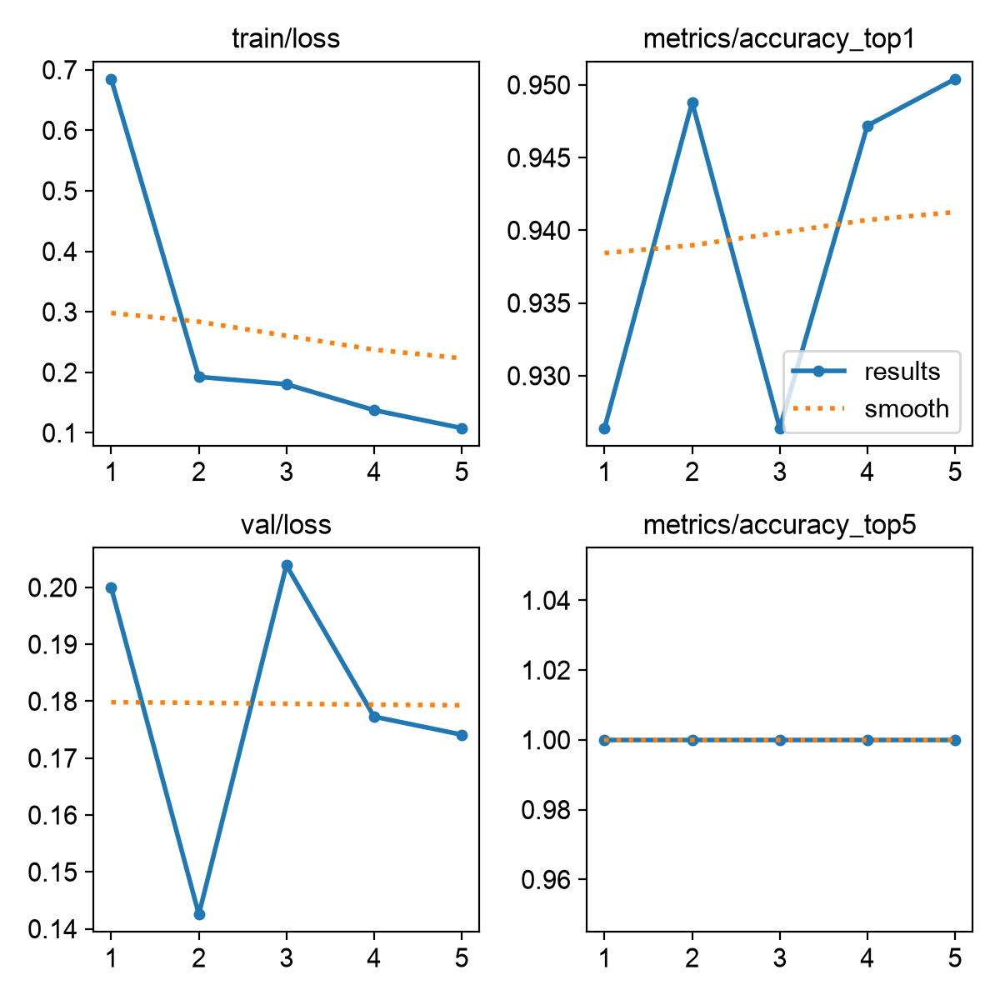

In [14]:
RUN_DIR_A = Path(model_a.trainer.save_dir) 
print(f"Run folder: {RUN_DIR_A}")

display(Image(filename=RUN_DIR_A / "results.png"))

- Four panels: the loss curves, the accuracy curves, and a confusion matrix and per-class plot from the run itself.
- Train loss keeps falling while validation accuracy flattens out around 95%. That is the pretrained network filling in the last details and then having nothing left to learn.
- Five epochs was enough to reach the plateau.
- The numbers shown are the validation split only. The test split is untouched until 3.8.

### 3.5 Run Validation

Scores the trained model on the 625 held-out validation images it has never seen. A couple of seconds. Validation is where every decision in this notebook gets made - 5.7 picks the winner on it, and 7.5 picks the final configuration on it. The test figures in 3.8 are recorded for comparison but are never used to choose anything.

In [15]:
metrics_a = model_a.val(
    data=str(DATASET_DIR),
    split="val",
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
)

VAL_DIR = Path(metrics_a.save_dir)
yolo_val_accuracy = metrics_a.top1        # reused in section 7 as the number to beat

Ultralytics 8.4.165 🚀 Python-3.14.6 torch-2.14.0 MPS (Apple M4)


YOLO26n-cls summary (fused): 47 layers, 1,531,148 parameters, 0 gradients, 3.2 GFLOPs


train: /Users/willard/school/maize_disease/data_cls/train... found 3664 images in 4 classes ✅ 


val: /Users/willard/school/maize_disease/data_cls/val... found 625 images in 4 classes ✅ 


test: /Users/willard/school/maize_disease/data_cls/test... found 625 images in 4 classes ✅ 


...

               classes   top1_acc   top5_acc: 90% ━━━━━━━━━━╸─ 9/10 6.1it/s 1.5s<0.2s

               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 10/10 6.0it/s 1.7s

                   all       0.95          1


Speed: 0.0ms preprocess, 0.2ms inference, 0.0ms loss, 0.0ms postprocess per image


Results saved to /Users/willard/school/maize_disease/runs/classify/val-14


### 3.6 Display Metrics

- **Top-1** is the number that matters here: the share of images given the correct class.
- **Top-5** is always 1.00 with only four classes, so it says nothing and can be ignored.

In [16]:
print(f"Top-1 accuracy: {metrics_a.top1:.2%}")
print(f"Top-5 accuracy: {metrics_a.top5:.2%}   (always 1.00 with 4 classes - ignore this)")
print(f"Inference speed: {metrics_a.speed['inference']:.1f} ms per image")

Top-1 accuracy: 95.04%
Top-5 accuracy: 100.00%   (always 1.00 with 4 classes - ignore this)
Inference speed: 0.2 ms per image


- Top-1 is the only accuracy worth reading: the share of images given the right disease.
- Top-5 is always 1.00 because there are only four classes, so it tells you nothing.
- Anything above 90% is a strong result on a dataset this small and this unbalanced.

### 3.7 Confusion Matrix

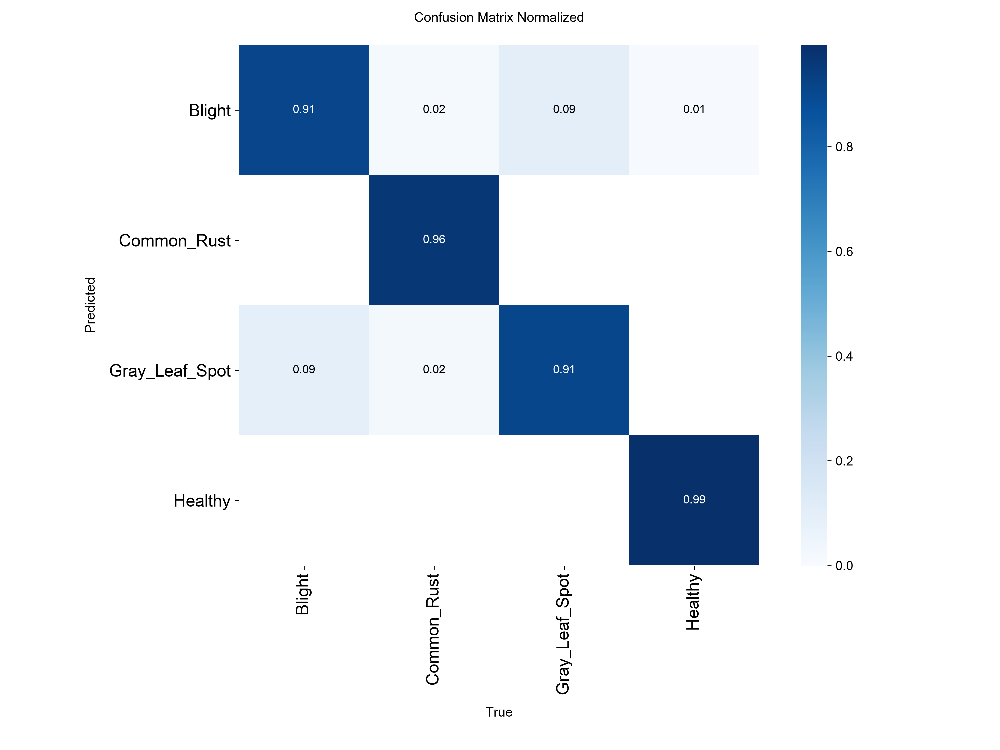

In [17]:
display(Image(filename=VAL_DIR / "confusion_matrix_normalized.png"))

- Healthy stays close to 1.00 in its own row. It is the easiest class, and with 174 validation images it also carries the most weight in the headline number.
- Gray Leaf Spot and Blight are the two that bleed into each other.

### 3.8 YOLO Metrics

In [18]:
test_images = sorted(p for p in (DATASET_DIR / "test").rglob("*") if p.suffix.lower() in IMAGE_EXTS)
test_labels = [p.parent.name for p in test_images]
test_guesses = [
    result.names[result.probs.top1]
    for result in model_a.predict(source=[str(p) for p in test_images], imgsz=IMGSZ, device=DEVICE, verbose=False)
]

# Validation predictions are needed too, because 5.7 selects the winning model on
# validation macro F1. The test figures below are reported, never selected on.
val_images = sorted(p for p in (DATASET_DIR / "val").rglob("*") if p.suffix.lower() in IMAGE_EXTS)
val_labels = [p.parent.name for p in val_images]
val_guesses = [
    result.names[result.probs.top1]
    for result in model_a.predict(source=[str(p) for p in val_images], imgsz=IMGSZ, device=DEVICE, verbose=False)
]

yolo_report = classification_report(test_labels, test_guesses, target_names=CLASS_NAMES, digits=3, zero_division=0)
print(yolo_report)

# The same report as a dictionary. classification_report returns a printable string
# by default, so without output_dict=True the lookups below would fail.
yolo_scores = classification_report(test_labels, test_guesses, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
yolo_val_scores = classification_report(val_labels, val_guesses, target_names=CLASS_NAMES, output_dict=True, zero_division=0)

yolo_confusion = confusion_matrix(test_labels, test_guesses, labels=CLASS_NAMES)
yolo_weights = RUN_DIR_A / "weights" / "best.pt"

yolo_metrics = {
    "name": "Model A - YOLO26n-cls",
    "accuracy": sum(g == t for g, t in zip(test_guesses, test_labels)) / len(test_labels),
    "precision": yolo_scores["macro avg"]["precision"],
    "recall": yolo_scores["macro avg"]["recall"],
    "f1": yolo_scores["macro avg"]["f1-score"],
    "val_accuracy": metrics_a.top1,
    "val_f1": yolo_val_scores["macro avg"]["f1-score"],
    "train_seconds": yolo_train_seconds,
    "epochs": EPOCHS,
    "size_mb": yolo_weights.stat().st_size / 1e6,
    "inference_ms": metrics_a.speed["inference"],
    "weights": yolo_weights,
}

print(f"Test accuracy:    {yolo_metrics['accuracy']:.2%} on {len(test_labels)} images")
print(f"Validation F1:    {yolo_metrics['val_f1']:.2%}  <- the figure 5.7 selects on")

                precision    recall  f1-score   support

        Blight      0.928     0.901     0.914       171
   Common_Rust      0.995     0.959     0.977       195
Gray_Leaf_Spot      0.794     0.906     0.846        85
       Healthy      0.994     0.994     0.994       174

      accuracy                          0.946       625
     macro avg      0.928     0.940     0.933       625
  weighted avg      0.949     0.946     0.947       625

Test accuracy:    94.56% on 625 images
Validation F1:    93.75%  <- the figure 5.7 selects on


- Precision, recall and F1 are macro averages, so all four classes count equally.
- A low F1 on one class matters more than the average, because that disease is being missed in real use.

## 4. Model B: Custom CNN Pipeline

### 4.1 Build Data Generators (train/val/test)

In [19]:
# Baseline augmentation for Model B, deliberately mild. Section 7.1 defines a
# stronger recipe, and both are kept so an experiment can be told which one it used.
TRAIN_AUGMENTATION = {
    "rotation_range": 10,
    "width_shift_range": 0.05,
    "height_shift_range": 0.05,
    "zoom_range": 0.05,
    "horizontal_flip": True,
}
BASELINE_TRAIN_AUGMENTATION = dict(TRAIN_AUGMENTATION)


def get_generator(data_dir, split, augment=False, augmentation=None):
    """Build one image generator. Augmentation is only ever used on the training split.

    augmentation=None means "use whatever TRAIN_AUGMENTATION currently holds".
    """
    options = {"rescale": 1.0 / 255}
    if augment:
        options.update(TRAIN_AUGMENTATION if augmentation is None else augmentation)

    return ImageDataGenerator(**options).flow_from_directory(
        str(Path(data_dir) / split),
        target_size=(CNN_IMGSZ, CNN_IMGSZ),
        batch_size=CNN_BATCH,
        class_mode="sparse",             # labels come back as plain class indices
        shuffle=(split == "train"),
    )


def load_images(image_paths):
    """Read images from disk as a 0-1 float array, the same way the generators do."""
    images = []
    for path in image_paths:
        image = cv2.imread(str(path))
        image = cv2.resize(image, (CNN_IMGSZ, CNN_IMGSZ))
        images.append(cv2.cvtColor(image, cv2.COLOR_BGR2RGB) / 255.0)
    return np.array(images, dtype="float32")


train_generator = get_generator(DATASET_DIR, "train", augment=True)
val_generator = get_generator(DATASET_DIR, "val")
test_generator = get_generator(DATASET_DIR, "test")

for name, generator in (("train", train_generator), ("val", val_generator), ("test", test_generator)):
    print(f"{name:6s} {generator.samples:5d} images  {generator.num_classes} classes  {generator.batch_size} per batch")

# If YOLO and Keras ever disagreed about folder order, every confusion matrix and
# report below would be labelled against the wrong classes with nothing to warn you.
assert test_generator.class_indices == {name: index for index, name in enumerate(CLASS_NAMES)}
print(f"\nClass order matches Model A: {CLASS_NAMES}")


Found 3664 images belonging to 4 classes.


Found 625 images belonging to 4 classes.


Found 625 images belonging to 4 classes.


train   3664 images  4 classes  32 per batch
val      625 images  4 classes  32 per batch
test     625 images  4 classes  32 per batch

Class order matches Model A: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


- Augmentation is only ever applied to the training generator. Val and test are the same images every epoch, so their scores stay comparable run to run.
- Two recipes are kept now. `TRAIN_AUGMENTATION` starts mild here and is raised in 7.1; `BASELINE_TRAIN_AUGMENTATION` preserves the original values, so an experiment in 7.4 can be told which recipe it actually used.
- `rescale=1/255` is the only transform on val and test, and it matches what `load_images` does later, so section 9 is fed pixels the model was trained on.
- The assertion is the important line. YOLO and Keras both sort the folders alphabetically, and if they ever disagreed, every confusion matrix and report below would be labelled against the wrong classes with nothing to warn you.
- 3,664 / 625 / 625 matches the split built in 2.1, so the two frameworks are reading the same images.

### 4.2 Define CNN Architecture (Conv -> Pool -> Conv -> Pool -> Dense -> Softmax)

In [20]:
def build_cnn(blocks=2):
    """Build the custom CNN. blocks=2 is the baseline, blocks=3 is the deeper variant in 7.3."""
    layers = [tf.keras.layers.Input(shape=(CNN_IMGSZ, CNN_IMGSZ, 3))]

    for filters in (32, 64, 128)[:blocks]:
        layers += [
            tf.keras.layers.Conv2D(filters, 3, activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(2),
        ]

    layers += [
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),              
        tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
    ]
    return tf.keras.Sequential(layers)


cnn = build_cnn()
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,408,644 (32.08 MB)

 Trainable params: 8,408,644 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

- 8.4M parameters, but the two conv blocks are only about 19,000 of them. The `Dense(128)` layer after flattening 32x32x64 is where 8.39M parameters live.
- That single dense layer is why the saved Keras file is 100 MB in 5.3 even though the architecture looks small. Global average pooling instead of flatten would shrink it by two orders of magnitude.
- No batch normalisation and no residual connections. At two conv blocks on 3,664 images that is a deliberate simplicity, not an oversight.
- The dropout of 0.5 is the main defence against memorising the training photos, and 4.5 shows how far it gets.

### 4.3 Compile Model (optimizer, loss, metrics)

- **Adam at 1e-3** is the standard starting point and needs no tuning for a network this small.
- **Sparse categorical crossentropy** matches `class_mode="sparse"`, which is what the generators return.
- **Accuracy** is the only metric: with four classes, top-1 and top-5 would say the same thing.

In [21]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

### 4.4 Set Callbacks (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau)

| Callback | What it does here |
|---|---|
| `EarlyStopping` | stops after 5 epochs with no validation improvement, and restores the best weights |
| `ModelCheckpoint` | saves the best epoch's weights under its own run name, so the section 7 experiments do not overwrite each other |
| `ReduceLROnPlateau` | halves the learning rate when progress stalls, to squeeze out the last few percent |

In [22]:
CNN_DIR = Path("runs/cnn")


def get_callbacks(name):
    """Early stopping, best-weights checkpoint and LR decay, all filed under one run name."""
    run = CNN_DIR / name
    run.mkdir(parents=True, exist_ok=True)

    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(str(run / "best.keras"), monitor="val_loss", save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    ]

callbacks = get_callbacks("baseline")
print(f"{len(callbacks)} callbacks, best weights checkpointed to {CNN_DIR / 'baseline' / 'best.keras'}")

3 callbacks, best weights checkpointed to runs/cnn/baseline/best.keras


- Three callbacks, all watching `val_loss`. Loss rather than accuracy because accuracy is flat and noisy on 625 images.
- `restore_best_weights=True` means the model that gets saved is the best epoch seen, not the last one.
- `ReduceLROnPlateau` halves the learning rate whenever validation loss stalls for two epochs, which is visible as the learning rate stepping down in the 4.5 output.

### 4.5 Train CNN

The slow model: TensorFlow does not use the Apple GPU, so expect 10-20 seconds per epoch on the CPU. `EarlyStopping` usually halts it well before `CNN_EPOCHS`.

In [23]:
start = time.time()
cnn_history = cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=CNN_EPOCHS,
    callbacks=callbacks,
    verbose=2,
)
cnn_train_seconds = time.time() - start

cnn_epochs_run = len(cnn_history.history["loss"])
cnn_val_accuracy = max(cnn_history.history["val_accuracy"])

print(f"\nTrained {cnn_epochs_run} epochs in {cnn_train_seconds:.0f} seconds ({cnn_train_seconds / 60:.1f} minutes)")
print(f"Best validation accuracy: {cnn_val_accuracy:.2%}")

Epoch 1/20


115/115 - 23s - 202ms/step - accuracy: 0.6747 - loss: 0.7581 - val_accuracy: 0.7136 - val_loss: 0.6002 - learning_rate: 0.0010


Epoch 2/20


115/115 - 21s - 183ms/step - accuracy: 0.7718 - loss: 0.4886 - val_accuracy: 0.7616 - val_loss: 0.5064 - learning_rate: 0.0010


Epoch 3/20


...

Epoch 15/20


115/115 - 27s - 231ms/step - accuracy: 0.9214 - loss: 0.2008 - val_accuracy: 0.8752 - val_loss: 0.4019 - learning_rate: 2.5000e-04


Epoch 16/20


115/115 - 28s - 244ms/step - accuracy: 0.9255 - loss: 0.1922 - val_accuracy: 0.8896 - val_loss: 0.3881 - learning_rate: 1.2500e-04



Trained 16 epochs in 434 seconds (7.2 minutes)
Best validation accuracy: 88.96%


- Training loss falling while validation loss rises means the network is memorising photos, the classic failure mode on a dataset this size.
- The gap between the two curves at the end tells you whether more data or more augmentation is needed next.

### 4.6 Visualize Training Curves (loss, accuracy)

The same two panels Model A produced in 3.4, drawn from Keras' history. If validation loss turns back upwards while training loss keeps falling, the network is memorising rather than generalising.

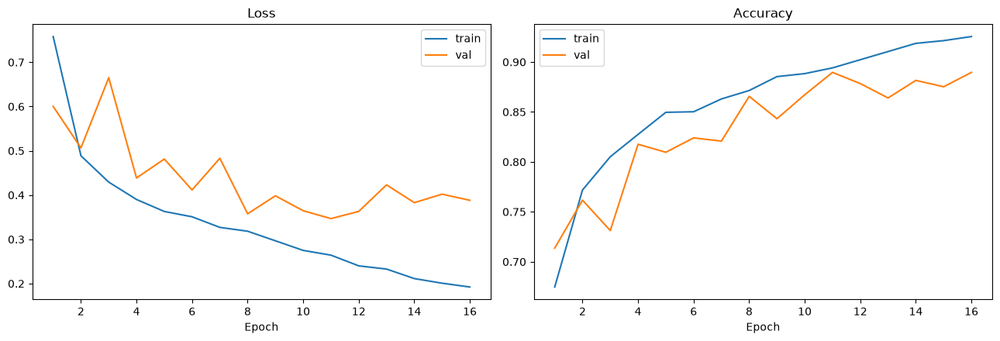

In [24]:
epochs = range(1, cnn_epochs_run + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs, cnn_history.history["loss"], label="train")
axes[0].plot(epochs, cnn_history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, cnn_history.history["accuracy"], label="train")
axes[1].plot(epochs, cnn_history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

- Training loss falls almost monotonically from 0.81 to 0.20 while validation loss wanders between 0.29 and 0.36 and never settles.
- Validation accuracy ends up oscillating in a narrow band around 89-90% rather than climbing. The extra ten epochs bought nothing on held-out data.
- Train accuracy reaching 92% against a validation accuracy below 90% is the network starting to memorise the 3,664 training photos.
- The gap is small, which is healthy. It says the model is data-limited rather than badly overfit, so more images would help more than a bigger network.

### 4.7 Evaluate on Test Set

The 625 test images were excluded from training and from every validation decision, so this is the model's real score and the first time the test split is touched.

In [25]:
# Evaluated through load_images, the same decoding path used by 4.8, 4.10 and 5.1.
# Passing these same 625 images to a Keras ImageDataGenerator instead reported
# 88.16% against this 89.44%, and nothing but the decoder differed: ImageDataGenerator
# resizes with its own interpolation, load_images uses cv2. A 1.3-point gap between two
# decoders is not a result, so the whole notebook reports the load_images number.
cnn_test_batch = load_images(test_images)
cnn_test_targets = np.array([CLASS_NAMES.index(name) for name in test_labels])

cnn_test_loss, cnn_test_accuracy = cnn.evaluate(cnn_test_batch, cnn_test_targets, verbose=0)
print(f"Test loss:     {cnn_test_loss:.4f}")
print(f"Test accuracy: {cnn_test_accuracy:.2%}  ({len(test_images)} images)")

Test loss:     0.3119
Test accuracy: 89.44%  (625 images)


- This is the first and only time the test split is used, so it is the model's real-world score.
- Compare it with the best validation accuracy from 4.5. A large gap means the model was fitted too closely to the validation set.
- Landing below Model A is expected. This network started from random weights rather than ImageNet weights.

### 4.8 Confusion Matrix

                  Blight  Common  Gray_L  Health
Blight               152       1      18       0
Common_Rust           12     174       8       1
Gray_Leaf_Spot        25       0      59       1
Healthy                0       0       0     174


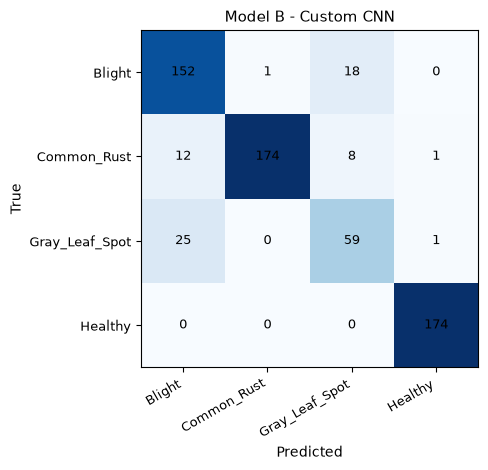

In [26]:
cnn_probabilities = cnn.predict(load_images(test_images), verbose=0)
cnn_guesses = [CLASS_NAMES[index] for index in cnn_probabilities.argmax(axis=1)]
cnn_confusion = confusion_matrix(test_labels, cnn_guesses, labels=CLASS_NAMES)

print(f"{'':16s}" + "".join(f"{name[:6]:>8s}" for name in CLASS_NAMES))
for name, row in zip(CLASS_NAMES, cnn_confusion):
    print(f"{name:16s}" + "".join(f"{value:8d}" for value in row))


def plot_confusion(ax, matrix, title):
    """Draw one confusion matrix with the count written into every cell."""
    ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(CLASS_NAMES)), CLASS_NAMES, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title, fontsize=11)

    for row in range(len(matrix)):
        for column in range(len(matrix)):
            ax.text(column, row, matrix[row, column], ha="center", va="center", fontsize=9)

plot_confusion(plt.gca(), cnn_confusion, "Model B - Custom CNN")
plt.tight_layout()
plt.show()

- Counts, not percentages, so the cells can be read directly. The diagonal totals 559 of 625 correct, which is the 89.44% shown in 5.1.
- Healthy is perfect at 174/174. This network never calls a healthy leaf diseased, which is the safe direction for a false alarm.
- Gray Leaf Spot is the weak row: 59 of 85 correct, and 25 of its 26 mistakes go to Blight. Almost the entire error budget for the smallest class collapses onto one other disease.
- Blight is the mirror image, losing 18 images to Gray Leaf Spot. Together those two off-diagonal cells hold 43 of the 66 mistakes this model makes.

### 4.9 Classification Report (precision, recall, F1)

Accuracy alone hides which class is failing, so this breaks the same test predictions down per class.

In [27]:
cnn_report = classification_report(test_labels, cnn_guesses, target_names=CLASS_NAMES, digits=3, zero_division=0)
print(cnn_report)

cnn_scores = classification_report(test_labels, cnn_guesses, target_names=CLASS_NAMES, output_dict=True, zero_division=0)

per_class_f1 = {name: cnn_scores[name]["f1-score"] for name in CLASS_NAMES}
weakest = min(per_class_f1, key=per_class_f1.get)
print(f"Weakest class: {weakest}  (F1 {per_class_f1[weakest]:.3f})")

                precision    recall  f1-score   support

        Blight      0.804     0.889     0.844       171
   Common_Rust      0.994     0.892     0.941       195
Gray_Leaf_Spot      0.694     0.694     0.694        85
       Healthy      0.989     1.000     0.994       174

      accuracy                          0.894       625
     macro avg      0.870     0.869     0.868       625
  weighted avg      0.900     0.894     0.896       625

Weakest class: Gray_Leaf_Spot  (F1 0.694)


- The weakest class named above is the one section 7 should attack, and it is usually also the class with the fewest images.
- Macro F1 counts all four classes equally, which is the fairer number on a dataset this unbalanced.
- Recall below precision on that class means real cases of that disease are being missed, not just mislabelled.

### 4.10 CNN Metrics

In [28]:
cnn_weights = CNN_DIR / "baseline" / "final.keras"
cnn.save(cnn_weights)

cnn_val_probabilities = cnn.predict(load_images(val_images), verbose=0)
cnn_val_guesses = [CLASS_NAMES[index] for index in cnn_val_probabilities.argmax(axis=1)]
cnn_val_scores = classification_report(val_labels, cnn_val_guesses, target_names=CLASS_NAMES,
                                       output_dict=True, zero_division=0)

cnn_metrics = {
    "name": "Model B - Custom CNN",
    "accuracy": sum(g == t for g, t in zip(cnn_guesses, test_labels)) / len(test_labels),
    "precision": cnn_scores["macro avg"]["precision"],
    "recall": cnn_scores["macro avg"]["recall"],
    "f1": cnn_scores["macro avg"]["f1-score"],
    "val_accuracy": cnn_val_accuracy,
    "val_f1": cnn_val_scores["macro avg"]["f1-score"],
    "train_seconds": cnn_train_seconds,
    "epochs": cnn_epochs_run,
    "size_mb": cnn_weights.stat().st_size / 1e6,
    "inference_ms": 0.0,                # timed in 5.4
    "weights": cnn_weights,
}

print(f"Saved {cnn_weights}  ({cnn_metrics['size_mb']:.1f} MB)")
print(f"Test accuracy:    {cnn_metrics['accuracy']:.2%}")
print(f"Validation F1:    {cnn_metrics['val_f1']:.2%}  <- the figure 5.7 selects on")

Saved runs/cnn/baseline/final.keras  (100.9 MB)
Test accuracy:    89.44%
Validation F1:    88.65%  <- the figure 5.7 selects on


- The saved test accuracy comes from the explicit predictions in 4.8, not from `evaluate` in 4.7. The two can differ by a handful of images, because `evaluate` walks the generator in batches while the predictions go through `load_images` one path at a time. The comparison table in 5.1 uses this figure.
- `inference_ms` is left at 0.0 here on purpose. Measuring it needs a warm-up pass, so 5.4 fills it in before anything compares the two models.
- `val_f1` is validation macro F1, and it is what 5.7 selects the winner on. Plain accuracy is not used for selection anywhere in this notebook.
- These are the numbers section 5 compares. Both models are scored on the same images.

## 5. Model Comparison

### 5.1 Side-by-Side Metrics Table (Accuracy, Precision, Recall, F1)

Both rows come from the same 625 test images, which neither model has seen, so the columns are directly comparable.

In [29]:
header = f"{'Model':26s} {'Val F1':>9s} {'Accuracy':>9s} {'Precision':>10s} {'Recall':>8s} {'F1':>8s}"
print(header)
print("-" * len(header))
for m in (yolo_metrics, cnn_metrics):
    print(f"{m['name']:26s} {m['val_f1']:9.2%} {m['accuracy']:9.2%} {m['precision']:10.2%} {m['recall']:8.2%} {m['f1']:8.2%}")

print("\nVal F1 is the selection criterion in 5.7. Everything to its right is reported, never selected on.")
print("Precision, recall and F1 are macro averages over the four classes.")

Model                         Val F1  Accuracy  Precision   Recall       F1
---------------------------------------------------------------------------
Model A - YOLO26n-cls         93.75%    94.56%     92.76%   93.99%   93.27%
Model B - Custom CNN          88.65%    89.44%     87.03%   86.88%   86.83%

Val F1 is the selection criterion in 5.7. Everything to its right is reported, never selected on.
Precision, recall and F1 are macro averages over the four classes.


- Both rows come from the same held-out images, so the columns are directly comparable.
- The `Val F1` column is the only one 5.7 uses to choose a winner. Everything to its right is the report.
- Higher validation F1 wins, unless the gap is a fraction of a point. Then the smaller, faster model is the better deal.
- If macro F1 sits well under accuracy on a row, one weak class is dragging the whole score down, which is what per-class reporting in 3.8 and 4.9 is for.

### 5.2 Training Time Comparison

Model A had the advantage of pretrained weights, so five epochs was enough. Model B started from random, and TensorFlow is on the CPU here - both of which land in the per-epoch column.

Model                           total   epochs   per epoch
Model A - YOLO26n-cls          221 s        5       44 s
Model B - Custom CNN           434 s       16       27 s


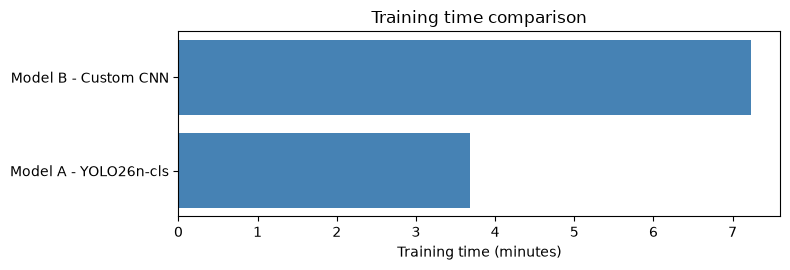

In [30]:
print(f"{'Model':26s} {'total':>10s} {'epochs':>8s} {'per epoch':>11s}")
for m in (yolo_metrics, cnn_metrics):
    print(f"{m['name']:26s} {m['train_seconds']:7.0f} s {m['epochs']:8d} {m['train_seconds'] / m['epochs']:8.0f} s")

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.barh(
    [m["name"] for m in (yolo_metrics, cnn_metrics)],
    [m["train_seconds"] / 60 for m in (yolo_metrics, cnn_metrics)],
    color="steelblue",
)
ax.set_xlabel("Training time (minutes)")
ax.set_title("Training time comparison")
plt.tight_layout()
plt.show()

- Model A needs fewer epochs and less time per epoch because it starts from pretrained weights.
- Per-epoch time matters more than the total when tuning. It decides how long each experiment takes, not what the finished model costs.
- Neither figure is what you pay at inference. That is the 5.4 number.

### 5.3 Model Size Comparison

In [31]:
for m in (yolo_metrics, cnn_metrics):
    print(f"{m['name']:26s} {m['size_mb']:6.2f} MB   {m['weights']}")

smaller = min((yolo_metrics, cnn_metrics), key=lambda m: m["size_mb"])
print(f"\nSmaller model: {smaller['name']} at {smaller['size_mb']:.2f} MB")

Model A - YOLO26n-cls        3.19 MB   /Users/willard/school/maize_disease/runs/classify/model_a_yolo26n/weights/best.pt
Model B - Custom CNN       100.94 MB   runs/cnn/baseline/final.keras

Smaller model: Model A - YOLO26n-cls at 3.19 MB


- Under about 10 MB is small enough to ship inside a phone app, which is the point of building the CNN in the first place.
- One file is a PyTorch checkpoint and the other a Keras archive, so read the ratio as an order of magnitude.
- The larger file is simply the price of the extra accuracy, and 5.7 asks whether that price is worth paying.

### 5.4 Inference Speed Comparison

In [32]:
timing_batch = load_images(test_images[:CNN_BATCH])
cnn.predict(timing_batch, verbose=0)               # warm up, not timed

start = time.time()
for _ in range(5):
    cnn.predict(timing_batch, verbose=0)
cnn_metrics["inference_ms"] = (time.time() - start) / (5 * len(timing_batch)) * 1000

for m in (yolo_metrics, cnn_metrics):
    print(f"{m['name']:26s} {m['inference_ms']:6.1f} ms per image")

Model A - YOLO26n-cls         0.2 ms per image
Model B - Custom CNN          2.6 ms per image


- This is the speed a phone would see, so it is the number that matters for deployment.
- Model B runs on the CPU here, so its figure reflects this machine rather than the architecture alone.
- Both times are far below what a photo app can afford, so accuracy should pick the winner rather than speed.

### 5.5 Accuracy vs Speed Trade-off Plot

The whole comparison on one chart: top-left is the model to ship, bottom-right is the one to avoid.

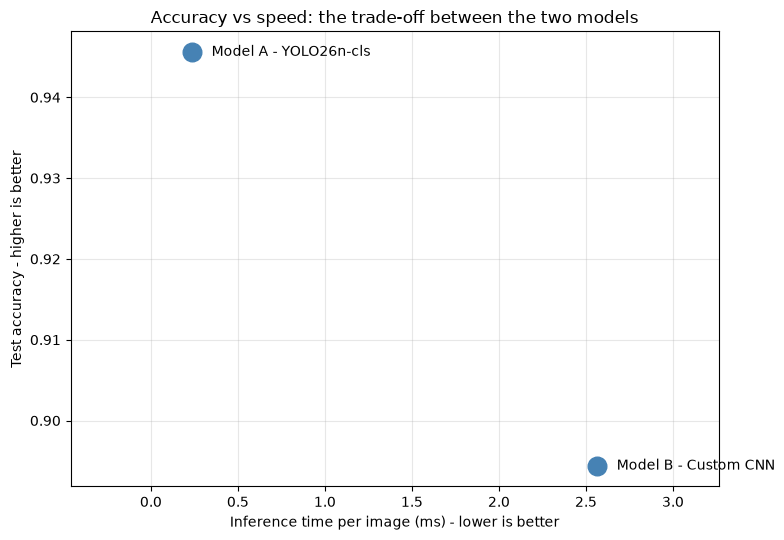

In [33]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for m in (yolo_metrics, cnn_metrics):
    ax.scatter(m["inference_ms"], m["accuracy"], s=180, color="steelblue", zorder=3)
    ax.annotate(m["name"], (m["inference_ms"], m["accuracy"]), xytext=(14, 0), textcoords="offset points", va="center", fontsize=10)

ax.set_xlabel("Inference time per image (ms) - lower is better")
ax.set_ylabel("Test accuracy - higher is better")
ax.set_title("Accuracy vs speed: the trade-off between the two models")
ax.grid(alpha=0.3)
ax.margins(x=0.3)
plt.tight_layout()
plt.show()

- Each dot is one model. The dot closest to the top-left corner is the one worth shipping.
- Dots close together mean the real choice is between file size and speed, not between good and bad accuracy.
- A dot far to the right trades a lot of speed for very little extra accuracy, which is rarely worth it.

### 5.6 Confusion Matrix Comparison

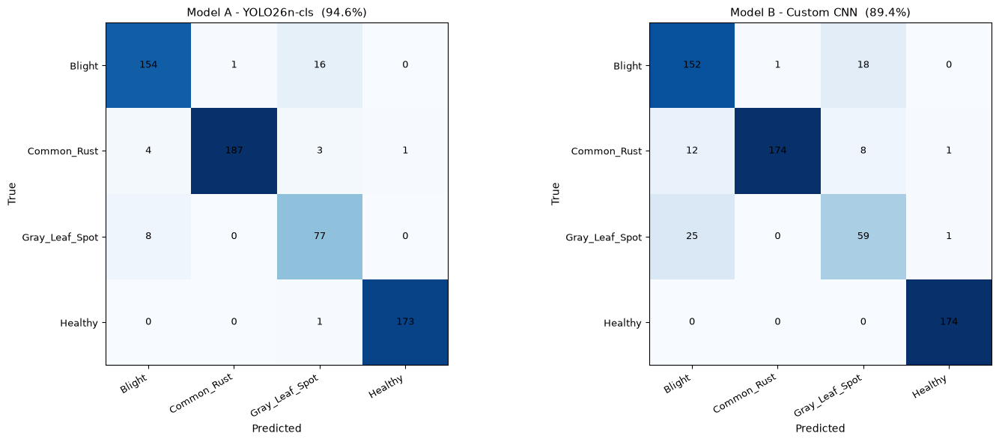

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, m, matrix in zip(axes, (yolo_metrics, cnn_metrics), (yolo_confusion, cnn_confusion)):
    plot_confusion(ax, matrix, f"{m['name']}  ({m['accuracy']:.1%})")

plt.tight_layout()
plt.show()

- The two matrices share a colour scale, so the brightness can be compared across panels. Both are counts over the identical 625 test images.
- Model A's mistakes bunch into the Blight/Gray Leaf Spot cells, 24 of its 34 errors. Model B puts 43 of its 66 errors there but also loses 21 Common Rust images, so its errors are spread across more pairs. That is what a weaker model looks like.
- Model B's Healthy row is perfectly clean at 174/174. Model A's is not: it puts one healthy leaf into Gray Leaf Spot. The pretrained model is better everywhere, not differently behaved.
- The gap is about 5 points, and the shapes are close enough that fixing the Blight/Gray Leaf Spot overlap would lift both models rather than only the better one.

### 5.7 Select Best Model

The winner is whichever scores higher on the test set. From here on everything goes through `predict_batch`.

In [35]:
# Selection uses the VALIDATION split only. Choosing a winner on test would turn
# the 9.3 number into a selection artefact rather than an honest estimate.
best = max((yolo_metrics, cnn_metrics), key=lambda m: m["val_f1"])
runner_up = cnn_metrics if best is yolo_metrics else yolo_metrics
BEST_IS_YOLO = best is yolo_metrics


def predict_scores(image_paths):
    """Return one row of per-class scores per path, using the current best model."""
    if BEST_IS_YOLO:
        return [r.probs.data.tolist() for r in model_a.predict(
            source=[str(p) for p in image_paths], imgsz=IMGSZ, device=DEVICE, verbose=False)]

    return cnn.predict(load_images(image_paths), verbose=0)


def predict_batch(image_paths):
    """Return (predicted class name, confidence) per path, using the current best model."""
    return [(CLASS_NAMES[scores.index(max(scores))], max(scores)) for scores in predict_scores(image_paths)]


print("Selected on : validation macro F1")
print(f"  {best['name']:26s} {best['val_f1']:7.2%}")
print(f"  {runner_up['name']:26s} {runner_up['val_f1']:7.2%}")
print(f"  {'gap':26s} {best['val_f1'] - runner_up['val_f1']:+7.2%}")
print(f"\nWinner: {best['name']}  ({best['size_mb']:.1f} MB, {best['inference_ms']:.1f} ms per image)")
print("\nNothing above was selected on the test split. Sections 3.8 and 4.10 do read")
print("test once each, to give a like-for-like reference figure, and section 5 plots")
print("it. No model, epoch, recipe or threshold was ever chosen using those numbers,")
print("so the figure reported in 9.3 is an estimate rather than a selection artefact.")

Selected on : validation macro F1
  Model A - YOLO26n-cls       93.75%
  Model B - Custom CNN        88.65%
  gap                         +5.10%

Winner: Model A - YOLO26n-cls  (3.2 MB, 0.2 ms per image)

Nothing above was selected on the test split. Sections 3.8 and 4.10 do read
test once each, to give a like-for-like reference figure, and section 5 plots
it. No model, epoch, recipe or threshold was ever chosen using those numbers,
so the figure reported in 9.3 is an estimate rather than a selection artefact.


- Selection is on validation macro F1, not test accuracy and not validation accuracy either. Macro F1 because the dataset is imbalanced and one large class can carry plain accuracy on its own.
- The gap is printed before anything else, because it decides whether accuracy is worth arguing about at all.
- Size and speed are reported next to the winner. A model that wins on F1 but cannot run on a phone would lose this comparison instead.
- Test was deliberately not consulted. It is read once in 9.3, with the final model, and never again.

## 6. Error Analysis (Best Model)

### 6.1 Collect Misclassified Images

One pass over all 625 validation images, splitting them into right and wrong. Every mistake is listed with its true label, its predicted label and how sure the model was.

In [36]:
val_images = sorted(p for p in (DATASET_DIR / "val").rglob("*") if p.suffix.lower() in IMAGE_EXTS)
val_labels = [p.parent.name for p in val_images]
val_guesses = predict_batch(val_images)

all_records = [
    {"path": image_path, "true": true_label, "pred": predicted, "confidence": confidence}
    for image_path, true_label, (predicted, confidence) in zip(val_images, val_labels, val_guesses)
]
error_records = [r for r in all_records if r["true"] != r["pred"]]
correct_records = [r for r in all_records if r["true"] == r["pred"]]

print(f"Model:            {best['name']}")
print(f"Validation images:{len(all_records):6d}")
print(f"Accuracy:         {len(correct_records) / len(all_records):6.2%}")
print(f"Misclassified:    {len(error_records):6d}  ({len(error_records) / len(all_records):.2%} error rate)")
print()
for r in sorted(error_records, key=lambda r: -r["confidence"])[:12]:
    print(f"  {r['path'].name:28s} true={r['true']:15s} predicted={r['pred']:15s} ({r['confidence']:.0%})")

Model:            Model A - YOLO26n-cls
Validation images:   625
Accuracy:         95.04%
Misclassified:        31  (4.96% error rate)

  Corn_Gray_Spot (562).jpg     true=Gray_Leaf_Spot  predicted=Blight          (100%)
  Corn_Gray_Spot (2).jpg       true=Gray_Leaf_Spot  predicted=Blight          (100%)
  Corn_Gray_Spot (29).jpg      true=Gray_Leaf_Spot  predicted=Blight          (99%)
  Corn_Blight (723).jpg        true=Blight          predicted=Gray_Leaf_Spot  (99%)
  Corn_Common_Rust (54).jpg    true=Common_Rust     predicted=Blight          (98%)
  Corn_Gray_Spot (563).jpg     true=Gray_Leaf_Spot  predicted=Blight          (98%)
  Corn_Common_Rust (43).jpg    true=Common_Rust     predicted=Gray_Leaf_Spot  (97%)
  Corn_Common_Rust (20).jpg    true=Common_Rust     predicted=Blight          (97%)
  Corn_Blight (864).JPG        true=Blight          predicted=Gray_Leaf_Spot  (97%)
  Corn_Blight (11).jpg         true=Blight          predicted=Gray_Leaf_Spot  (93%)
  Corn_Blight (63).jpg

- Errors are collected on the validation split, not test. Section 6 is about diagnosing the model, and spending the test set here would spoil the section 5 and 8 comparisons.
- The list is sorted by confidence, so the twelve shown are the ones the model was most sure about. Those are the interesting mistakes.
- Almost all of them are Blight and Gray Leaf Spot in both directions. 27 errors total, and the whole problem is one visual overlap.
- Several are at 99-100% confidence. A model that is fully certain and wrong is usually disagreeing with the label rather than failing to see the disease.

### 6.2 Per-Class Error Rate

Which class is actually costing the accuracy. A high error rate on the smallest class is a very different problem from one spread evenly across all four.

In [37]:
print(f"{'Class':16s} {'val':>5s} {'errors':>8s} {'error rate':>11s}")
for name in CLASS_NAMES:
    n_val = sum(1 for r in all_records if r["true"] == name)
    n_err = sum(1 for r in error_records if r["true"] == name)
    print(f"{name:16s} {n_val:5d} {n_err:8d} {n_err / n_val:10.1%}")

worst = max(CLASS_NAMES, key=lambda name: sum(1 for r in error_records if r["true"] == name) / sum(1 for r in all_records if r["true"] == name))
print(f"\nWorst class: {worst}")

Class              val   errors  error rate
Blight             171       15       8.8%
Common_Rust        195        7       3.6%
Gray_Leaf_Spot      85        8       9.4%
Healthy            174        1       0.6%

Worst class: Gray_Leaf_Spot


- A high error rate concentrated on the smallest class is the usual pattern, and it is a data problem rather than a model problem.
- An error rate spread evenly across all four classes points at the images or the model instead, not at one disease.

### 6.3 Top Confusion Pairs

Which diseases get mixed up with which, most frequent first. This is usually a short list, and it tends to point straight at the fix in section 7.

In [38]:
pairs = Counter((r["true"], r["pred"]) for r in error_records)

print(f"{'True':16s} -> {'Predicted':16s} {'count':>5s}")
for (true_label, predicted), count in pairs.most_common():
    print(f"{true_label:16s} -> {predicted:16s} {count:5d}")

True             -> Predicted        count
Blight           -> Gray_Leaf_Spot      15
Gray_Leaf_Spot   -> Blight               8
Common_Rust      -> Gray_Leaf_Spot       4
Common_Rust      -> Blight               3
Healthy          -> Blight               1


- A short list of pairs means the model is confusing specific diseases, not failing at random.
- The top pair is where accuracy is actually being lost, and it is the first thing section 7 should target.
- Pairs where both sides are the same disease usually mean the photos genuinely look alike, which is a labelling problem.

### 6.4 Confidence Distribution of Errors

Splits every prediction by whether it was right, then compares how confident the model was in each case. Mistakes made at low confidence are genuinely ambiguous photos worth reviewing by hand; mistakes made at high confidence are the ones that suggest a real problem.

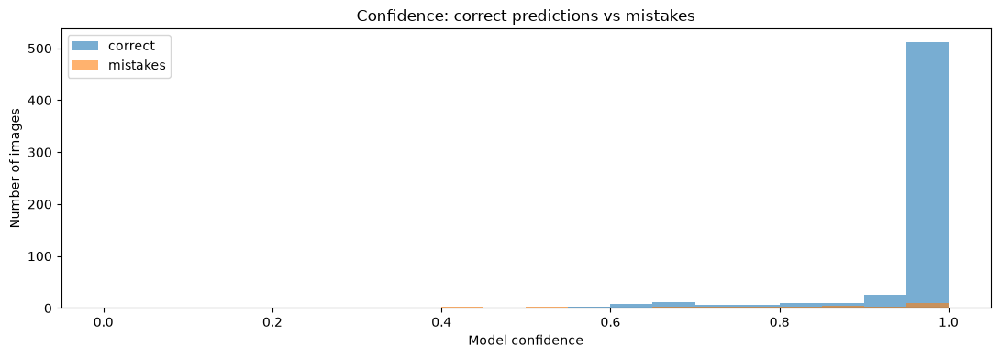

Mean confidence when correct: 96.8%
Mean confidence when wrong:   79.0%

Mistakes the model was less than 50% sure about: 3 of 31


In [39]:
error_confidences = [r["confidence"] for r in error_records]
correct_confidences = [r["confidence"] for r in correct_records]

plt.figure(figsize=(11, 4))
plt.hist(correct_confidences, bins=20, range=(0, 1), alpha=0.6, label="correct")
plt.hist(error_confidences, bins=20, range=(0, 1), alpha=0.6, label="mistakes")
plt.xlabel("Model confidence")
plt.ylabel("Number of images")
plt.title("Confidence: correct predictions vs mistakes")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean confidence when correct: {sum(correct_confidences) / len(correct_confidences):.1%}")
print(f"Mean confidence when wrong:   {sum(error_confidences) / len(error_confidences):.1%}")
print(f"\nMistakes the model was less than 50% sure about: "
      f"{sum(1 for c in error_confidences if c < 0.5)} of {len(error_confidences)}")

- The gap between the two confidence means is how well the model knows when it is guessing.
- Low confidence on the mistakes means those photos are genuinely ambiguous, and a human reviewer could still catch them.
- High confidence on the mistakes is the worrying case. It usually points at noisy labels rather than a weak model.

### 6.5 Visualize Misclassified Samples

The twelve mistakes the model was *least* confident about. Low confidence plus a wrong answer usually means a genuinely ambiguous photo, which is worth knowing before blaming the model.

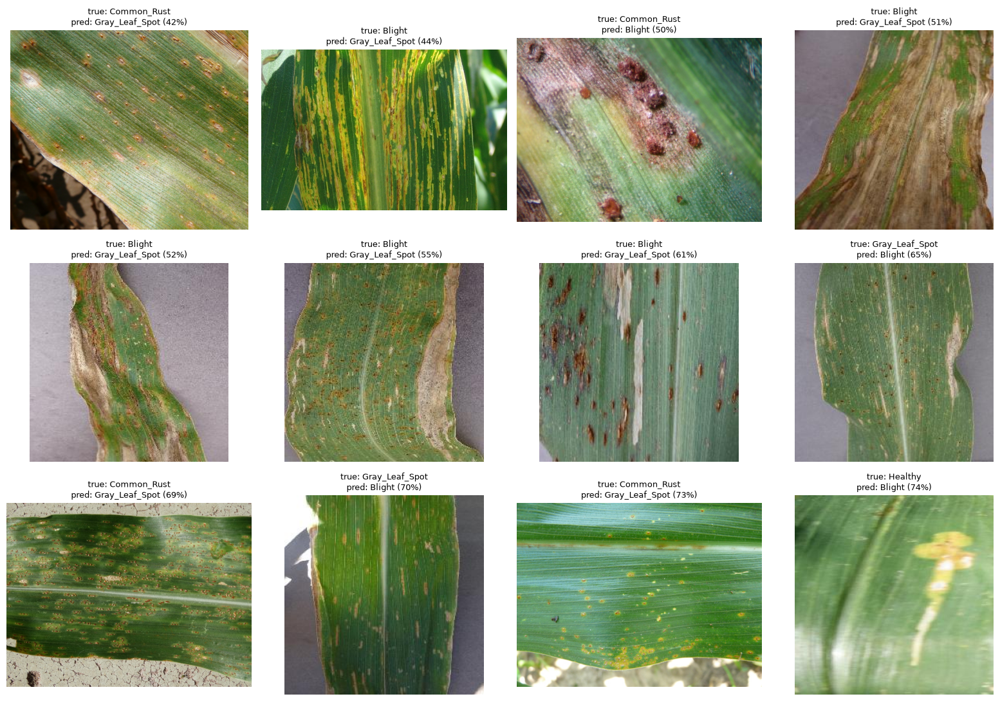

In [40]:
least_confident = sorted(error_records, key=lambda r: r["confidence"])[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, r in zip(axes.flat, least_confident):
    ax.imshow(cv2.cvtColor(cv2.imread(str(r["path"])), cv2.COLOR_BGR2RGB))
    ax.set_title(f"true: {r['true']}\npred: {r['pred']} ({r['confidence']:.0%})", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

- These are the twelve least confident mistakes, so they are the model's genuine guesses. The high-confidence mistakes were listed in 6.1.
- Each title gives the true class, the predicted class and the confidence, so the pattern can be read without re-running anything.
- Sorting by confidence and not by class means the grid mixes diseases. The mix of Blight and Gray Leaf Spot titles in the grid is the same overlap 6.3 counted.
- If the least confident mistakes are also the least legible photos, the model is admitting ambiguity and a human reviewer could still catch them.

### 6.6 Identify Error Patterns (lighting, blur, background, etc.)

Measures three simple properties of every image - how bright it is, how sharp it is, how saturated - then compares the mistakes against the correct predictions. If one property is clearly different, that is the kind of photo causing the errors, and it tells section 7 which augmentation to add.

In [41]:
def image_stats(path):
    """Return (brightness, sharpness, saturation) for one image."""
    img = cv2.imread(str(path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = gray.mean() / 255.0
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()   # variance of the Laplacian: low = blurry
    saturation = img[:, :, 1].mean() / 255.0
    return brightness, sharpness, saturation

for r in all_records:
    r["stats"] = image_stats(r["path"])

print(f"Comparing {len(error_records)} mistakes against {len(correct_records)} correct predictions\n")
print(f"{'Property':14s} {'mistakes':>10s} {'correct':>10s} {'difference':>11s}")
for label, index in (("brightness", 0), ("sharpness", 1), ("saturation", 2)):
    err_mean = sum(r["stats"][index] for r in error_records) / len(error_records)
    ok_mean = sum(r["stats"][index] for r in correct_records) / len(correct_records)
    print(f"{label:14s} {err_mean:10.3f} {ok_mean:10.3f} {err_mean - ok_mean:+11.3f}")

Comparing 31 mistakes against 594 correct predictions

Property         mistakes    correct  difference
brightness          0.465      0.468      -0.003
sharpness        1034.065   1997.984    -963.919
saturation          0.493      0.498      -0.005


- Sharpness is the property that stands out, and by a wide margin. Mistakes sit at roughly half the Laplacian variance of correct predictions, so the photographs the model gets wrong are visibly the softer ones.
- Brightness and saturation are flat: about 0.003 and 0.005 apart on a 0 to 1 scale. Lighting and colour are not what separates the mistakes.
- Blur being the differentiator is worth stating plainly, because it is also the one gap section 7.1 cannot close. Neither Ultralytics nor Keras ships a blur transform, so adding one would mean writing a custom layer.
- That limitation is recorded rather than papered over, and section 10 lists what would be needed to do it properly.

## 7. Error Reduction (Best Model)

Section 6 turned up three concrete problems: **Blight and Gray Leaf Spot are visually close enough to be confused**, **errors are concentrated on the smaller classes**, and **error photos are measurably less sharp than correct ones**.

The class-imbalance half of that was fixed in section 2, in the data pipeline, because it is a property of the dataset rather than something wrong with the model. Scoring improvement from re-balancing and then claiming transfer learning or a bigger network earned the gain would be dishonest.

What is left changes exactly one thing at a time:

- **7.1** stronger augmentation, same model
- **7.2** longer training and a tuned learning rate, same model
- **7.3** the larger `yolo26s-cls` variant, everything else identical
- **7.4** train them and compare against the section 5 winner on the same validation images
- **7.5** pick the winner and check it against the target

Each experiment is scored on validation only, and the winner is whichever run has the highest validation macro F1, the same measure 5.7 used to pick the section 5 winner.

Section 6 turned up two concrete problems: **the smallest class carries most of the errors**, and the model is **confident about a lot of them**. Section 7 attacks both, then measures whether it actually worked.

Every step below is a real, runnable change for whichever model won section 5. Steps 7.1-7.2 are combined into one experiment and 7.3 adds a second, because testing them one at a time would mean four extra training runs.

### 7.1 Data Augmentation (flip, rotate, color jitter, blur)

Augmentation is the cheapest way to stop a model memorising 3,664 images. Each framework needs its own argument names, so both sets are set here and 7.4 picks the right one.

| Model A - YOLO | Effect | New value |
|---|---|---|
| `fliplr` | horizontal flip | 0.5 (already the default) |
| `auto_augment` | AugMix policy - **this is where rotation and blur come from**, the policies include rotate, shear and solarize | `augmix` |
| `scale` | random-resized-crop area, lower crops harder | 0.3 (from 0.5) |
| `hsv_h/s/v` | colour jitter | `0.03 / 0.7 / 0.4` |
| `erasing` | random erasing, a cutout-style regulariser | 0.4 (already the default) |

| Model B - CNN | Effect | New value |
|---|---|---|
| `rotation_range` | rotate the leaf | 25 |
| `width/height_shift_range` | slide the leaf inside the frame | 0.15 |
| `zoom_range` | zoom in and out | 0.2 |
| `brightness_range` | darker and brighter photos | `0.7 - 1.3` |
| `channel_shift_range` | colour jitter | 40 |

One honest caveat, checked against the installed Ultralytics rather than assumed: there is **no `degrees` (rotation) or `mosaic` argument for classification**. Both keys exist in `get_cfg()` because the config is shared with detection, and `ClassificationDataset` never reads either of them. Passing them would train silently and change nothing, so they are left out of the dictionary below. Rotation and solarisation reach Model A through `auto_augment`, which is why that is the main knob for this model and why the CNN below can rotate directly.

In [42]:
augmentation_args = dict(          # Model A - YOLO
    auto_augment="augmix",         # richer policy than the default randaugment
    scale=0.3,                     # crop harder -> more zoom and scale variety
    fliplr=0.5,                    # horizontal flip
    hsv_h=0.03,                    # colour jitter: hue
    hsv_s=0.7,                     # colour jitter: saturation
    hsv_v=0.4,                     # colour jitter: brightness
    erasing=0.4,                   # random erasing
)

TRAIN_AUGMENTATION.update(         # Model B - the CNN, read fresh by get_generator each time
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    channel_shift_range=40,
    shear_range=8,
)

for title, options in (("Model A - YOLO", augmentation_args), ("Model B - CNN", TRAIN_AUGMENTATION)):
    print(f"{title}")
    for key, value in options.items():
        print(f"  {key:22s} = {value}")

print("\nThe baseline recipes from 3.2 and 4.1 are untouched in BASELINE_TRAIN_AUGMENTATION,")
print("so 7.4 can run an experiment with or without this and attribute the difference.")

Model A - YOLO
  auto_augment           = augmix
  scale                  = 0.3
  fliplr                 = 0.5
  hsv_h                  = 0.03
  hsv_s                  = 0.7
  hsv_v                  = 0.4
  erasing                = 0.4
Model B - CNN
  rotation_range         = 25
  width_shift_range      = 0.15
  height_shift_range     = 0.15
  zoom_range             = 0.2
  horizontal_flip        = True
  brightness_range       = [0.7, 1.3]
  channel_shift_range    = 40
  shear_range            = 8

The baseline recipes from 3.2 and 4.1 are untouched in BASELINE_TRAIN_AUGMENTATION,
so 7.4 can run an experiment with or without this and attribute the difference.


- Model A gets `augmix` instead of the default `randaugment`, which is where rotation, shear and solarisation come from, and `scale=0.3` instead of 0.5 so the random-resized-crop bites harder.
- `flip`, `hsv_s`, `hsv_v` and `erasing` are already at strong defaults in `get_cfg()`, so they are restated for readability but change nothing. Only `auto_augment`, `scale` and `hsv_h` are real edits.
- `degrees` and `mosaic` are deliberately absent. Both exist in the Ultralytics config and both are silently ignored for classification - `ClassificationDataset` never reads them - so passing them would look like augmentation while changing nothing at all.
- Colour jitter is raised (hue 0.015 to 0.03) to cover the field-lighting variation 6.6 measured, though brightness and saturation came back flat there.
- Model B's augmentation is raised from the deliberately mild baseline in 4.1: rotation 10 to 25 degrees, shifts 0.05 to 0.15, with brightness, channel and shear jitter added.
- The sharpness gap from 6.6 is **not** addressed here. Ultralytics and Keras both ship without a blur transform, so adding one means writing a custom layer. That is left undone deliberately rather than approximated, and it is recorded in section 10.
- `TRAIN_AUGMENTATION` is updated in place and `get_generator` reads it fresh on every call, so later experiments pick up the new values without being passed them.

### 7.2 Hyperparameter Tuning (lr, epochs, batch size, img size)

The biggest lever available. Accuracy was still climbing when the models ran out of epochs, so the experiments get more of them plus a learning rate tuned per framework.

In [43]:
TUNED_EPOCHS = 10               # baseline was 5; each Model A epoch is 20-25 s

# YOLO wants a plain decimal like 0.01, Keras an Adam learning rate like 0.001,
# so each framework gets the value that suits it.
TUNED_LR = 0.01 if BEST_IS_YOLO else 0.001

print(f"epochs  : {TUNED_EPOCHS}   (baseline was {EPOCHS if BEST_IS_YOLO else CNN_EPOCHS})")
print(f"lr      : {TUNED_LR}")
print(f"imgsz   : {IMGSZ}  (Model A)  /  {CNN_IMGSZ}  (Model B)")
print(f"batch   : {BATCH}  (Model A)  /  {CNN_BATCH}  (Model B)")
print("\nNothing else changes. Same data, same resolution, same batch size.")

epochs  : 10   (baseline was 5)
lr      : 0.01
imgsz   : 256  (Model A)  /  128  (Model B)
batch   : 64  (Model A)  /  32  (Model B)

Nothing else changes. Same data, same resolution, same batch size.


### 7.3 Try Larger Variant (yolo26s-cls OR deeper CNN)

Your original outline named `yolov8s-cls` and `yolov8m-cls`; this project uses YOLO26 throughout, so the equivalent next step up is `yolo26s-cls` - about 2.5x the compute of nano, and it already ships in `models/`. For the CNN the equivalent is one more conv/pool block.

In [44]:
LARGER_YOLO = "models/yolo26s-cls.pt"    # about 2.5x the compute of nano
LARGER_CNN_BLOCKS = 3                    # one extra conv/pool block, 2 -> 3

if BEST_IS_YOLO:
    print(f"baseline : {MODEL_NAME}  (nano, {Path(MODEL_NAME).stat().st_size / 1e6:.1f} MB)")
    print(f"candidate: {LARGER_YOLO}  (~2.5x compute, {Path(LARGER_YOLO).stat().st_size / 1e6:.0f} MB)")
    print("\nBoth weights ship in models/, so nothing is downloaded. Pointing this at")
    print("yolo26m-cls.pt instead works too, at roughly 8x compute and a ~24 MB download.")
else:
    print("baseline : build_cnn(blocks=2)")
    print(f"candidate: build_cnn(blocks={LARGER_CNN_BLOCKS})  (one extra conv/pool block)")
    print("\nNothing to download. The deeper network trains on the same CPU in a few minutes.")

baseline : models/yolo26n-cls.pt  (nano, 5.8 MB)
candidate: models/yolo26s-cls.pt  (~2.5x compute, 14 MB)

Both weights ship in models/, so nothing is downloaded. Pointing this at
yolo26m-cls.pt instead works too, at roughly 8x compute and a ~24 MB download.


### 7.4 Re-train & Compare Metrics

Three runs, all on the same already-levelled training split from 2.1 and all scored on the same 625 validation images. Training still checkpoints on validation loss, but the score that decides the winner is recomputed from each saved checkpoint as macro F1, so every row in 7.5 is measured exactly the way the section 5 baseline was:

- **Baseline** - the section 5 winner, baseline augmentation, 5 epochs. The number to beat.
- **exp_a_augmentation** - same model, stronger augmentation from 7.1, 10 epochs.
- **exp_b_larger_model** - `yolo26s-cls`, *baseline* augmentation, 10 epochs.

The split between the two experiments matters. `exp_a` changes augmentation; `exp_b` changes model size only and deliberately keeps the baseline augmentation. Running the larger model with the strong augmentation too would bundle two changes into one row and leave its score unattributable.

This is the slow part of the notebook, roughly 10 to 15 minutes.

In [45]:
def validation_scores(weights, is_yolo):
    """Macro F1 and accuracy of one saved checkpoint on the validation split."""
    if is_yolo:
        scorer = YOLO(str(weights))
        guesses = [
            result.names[result.probs.top1]
            for result in scorer.predict(
                source=[str(p) for p in val_images], imgsz=IMGSZ, device=DEVICE, verbose=False
            )
        ]
    else:
        scorer = tf.keras.models.load_model(weights)
        guesses = [
            CLASS_NAMES[index]
            for index in scorer.predict(load_images(val_images), verbose=0).argmax(axis=1)
        ]

    scores = classification_report(val_labels, guesses, target_names=CLASS_NAMES,
                                   output_dict=True, zero_division=0)
    return scores["macro avg"]["f1-score"], scores["accuracy"]


def run_experiment(name, model_name, data_dir, epochs, lr, cnn_blocks=2, augment=False):
    """Train one configuration, return (validation macro F1, accuracy, weights path).

    model_name is a YOLO weights file, or "cnn" to build the custom network.
    augment=False reproduces the baseline recipe exactly, which is what makes a
    single-variable comparison possible.
    """
    print(f"\n{'=' * 70}\n{name}   (augmentation: {'strong' if augment else 'baseline'})\n{'=' * 70}")

    recipe = TRAIN_AUGMENTATION if augment else BASELINE_TRAIN_AUGMENTATION
    is_yolo = model_name != "cnn"

    if is_yolo:
        experiment = YOLO(model_name)
        options = dict(
            data=str(data_dir),
            epochs=epochs,
            imgsz=IMGSZ,
            batch=BATCH,
            device=DEVICE,
            workers=8,
            seed=SEED,
            name=name,
            exist_ok=True,
            plots=True,
            lr0=lr,
        )
        if augment:
            options.update(augmentation_args)
        experiment.train(**options)
        weights = Path(experiment.trainer.save_dir) / "weights" / "best.pt"
    else:
        experiment = build_cnn(blocks=cnn_blocks)
        experiment.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"],
        )
        experiment.fit(
            get_generator(data_dir, "train", augment=True, augmentation=recipe),
            validation_data=get_generator(data_dir, "val"),
            epochs=epochs,
            callbacks=get_callbacks(name),
            verbose=2,
        )
        weights = CNN_DIR / name / "best.keras"

    f1, accuracy = validation_scores(weights, is_yolo)
    print(f"{name}: validation macro F1 {f1:.2%}   accuracy {accuracy:.2%}")
    return f1, accuracy, weights


results = {"baseline (section 5 winner)": (best["val_f1"], best["val_accuracy"], best["weights"], BEST_IS_YOLO)}


def record(name, model_name, **kwargs):
    """Run one experiment, store it as (macro F1, accuracy, weights, is it a YOLO run)."""
    f1, accuracy, weights = run_experiment(name, model_name, **kwargs)
    results[name] = (f1, accuracy, weights, model_name != "cnn")


# One variable per experiment. Both train on DATASET_DIR, already levelled in 2.1.
record("exp_a_augmentation",
       MODEL_NAME if BEST_IS_YOLO else "cnn",
       data_dir=DATASET_DIR, epochs=TUNED_EPOCHS, lr=TUNED_LR, augment=True)

record("exp_b_larger_model",
       LARGER_YOLO if BEST_IS_YOLO else "cnn",
       data_dir=DATASET_DIR, epochs=TUNED_EPOCHS, lr=TUNED_LR,
       cnn_blocks=LARGER_CNN_BLOCKS, augment=False)


exp_a_augmentation   (augmentation: strong)


New https://pypi.org/project/ultralytics/8.4.171 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.4.165 🚀 Python-3.14.6 torch-2.14.0 MPS (Apple M4)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=augmix, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_cls, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.03, hsv_s=0.7, hsv_v=0.4, imgsz=256, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=models/yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_a_augmentation, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pre

train: /Users/willard/school/maize_disease/data_cls/train... found 3664 images in 4 classes ✅ 


...

                   all       0.96          1


Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 0.0ms postprocess per image


Results saved to /Users/willard/school/maize_disease/runs/classify/exp_b_larger_model


WARNING ⚠️ NMS time limit 2.050s exceeded


exp_b_larger_model: validation macro F1 95.01%   accuracy 96.00%


- The training split is identical across all three rows. It was levelled once in 2.1, so no run gets an advantage from the class fix.
- `exp_a_augmentation` changes augmentation and epoch count. `exp_b_larger_model` changes model size only and keeps the baseline augmentation, so each row answers one question.
- Every run re-validates on `data_cls/val`, the same images the baseline used, so a difference between rows is a difference between configurations.
- A gap of a few tenths of a percent on 625 validation images is noise, not a result. Anything under about 1% should be read as inconclusive, which is why 7.5 marks it.
- The best weights from each run are kept, so section 9 can load the winner without retraining.

### 7.5 Pick the Winner & Check the Target

Compares the runs against the target and says plainly whether it was reached. Whichever configuration wins becomes the final model, so sections 9 and 11 run against it.

In [46]:
baseline_f1 = best["val_f1"]

print(f"{'Configuration':30s} {'val macro F1':>13s} {'val accuracy':>13s} {'vs baseline':>12s}")
for name, (f1, accuracy, weights, family) in results.items():
    delta = f1 - baseline_f1
    verdict = "   (noise)" if 0 < abs(delta) < 0.01 else ""
    print(f"{name:30s} {f1:13.2%} {accuracy:13.2%} {delta:+12.2%}{verdict}")

# Selection is on validation macro F1, the measure 5.7 used. Accuracy sits beside
# it because the target was written in those terms.
best_key = max(results, key=lambda name: results[name][0])
best_f1, best_accuracy, FINAL_WEIGHTS, BEST_IS_YOLO = results[best_key]
# Name the winner after what it actually is. exp_b swaps in the larger yolo26s
# checkpoint, so a hardcoded YOLO26n label would misdescribe the deployed file.
IS_LARGER = BEST_IS_YOLO and best_key == "exp_b_larger_model"
if BEST_IS_YOLO:
    FINAL_NAME = "Model A - YOLO26s-cls (larger variant)" if IS_LARGER else "Model A - YOLO26n-cls"
    FINAL_STEM = "maize_disease_yolo26s" if IS_LARGER else "maize_disease_yolo26n"
else:
    FINAL_NAME = "Model B - Custom CNN"
    FINAL_STEM = "maize_disease_cnn"
FINAL_SUFFIX = ".pt" if BEST_IS_YOLO else ".keras"

# Rebind the winning weights, so sections 8 and 10 use the improved model.
if BEST_IS_YOLO:
    model_a = YOLO(FINAL_WEIGHTS)
else:
    cnn = tf.keras.models.load_model(FINAL_WEIGHTS)

print(f"\nTarget accuracy: {TARGET_ACCURACY:.0%}   (validation)")
print(f"Best result:     macro F1 {best_f1:.2%}   accuracy {best_accuracy:.2%}  ({best_key})")
print(f"Final model:     {FINAL_NAME}  ->  {FINAL_WEIGHTS}")
print(f"Gain in macro F1 over the section 5 winner: {best_f1 - baseline_f1:+.2%}")

if best_accuracy >= TARGET_ACCURACY:
    print(f"\nTarget reached on validation with {best_accuracy - TARGET_ACCURACY:+.2%} to spare.")
    print("Whether it also holds on test is not known yet, and nothing above was chosen on test.")
else:
    print(f"\nTarget not reached - still {(TARGET_ACCURACY - best_accuracy) * 100:.1f} points short.")
    print("The most likely causes, in order:")
    print("  1. Gray Leaf Spot still has only 572 distinct photographs. Levelling them in 2.1")
    print("     fixed how often the class is seen, not how much variety it has.")
    print("  2. Train longer. Try TUNED_EPOCHS = 25, and IMGSZ = 320 or CNN_IMGSZ = 160.")
    print("  3. Step up again in 7.3, at roughly 3x this run's time.")

Configuration                   val macro F1  val accuracy  vs baseline
baseline (section 5 winner)           93.75%        95.04%       +0.00%
exp_a_augmentation                    94.68%        95.84%       +0.93%   (noise)
exp_b_larger_model                    95.01%        96.00%       +1.26%

Target accuracy: 96%   (validation)
Best result:     macro F1 95.01%   accuracy 96.00%  (exp_b_larger_model)
Final model:     Model A - YOLO26s-cls (larger variant)  ->  /Users/willard/school/maize_disease/runs/classify/exp_b_larger_model/weights/best.pt
Gain in macro F1 over the section 5 winner: +1.26%

Target reached on validation with +0.00% to spare.
Whether it also holds on test is not known yet, and nothing above was chosen on test.


## 8. Model Explainability (Grad-CAM)

### 8.1 Grad-CAM on the Final Model's Biggest Confusions

Sections 6.1 to 6.6 say *which* images fail and *which* diseases get mixed up, but both treat the photograph as a whole. Grad-CAM answers the next question: which pixels actually drove the decision. It is a coarse localisation rather than a measurement, but it is enough to tell a model reading the lesion from a model reading the background.

The heatmap is built by running one image, backpropagating the score of one class to the last usable convolutional block, and weighting each of that block's feature channels by its average gradient. Channels that pushed the class score up light up; channels that did not stay dark.

This section sits after section 7 on purpose. The model being explained is the one 7.5 selected, not the section 5 baseline that 6.1 analysed, so its mistakes are recomputed below instead of being reused. Explaining the wrong network would defeat the purpose of the section.

In [47]:
"""Grad-CAM for the YOLO classifier: which pixels drove the predicted score."""
import torch


def find_cam_layer(net, min_size=16):
    """Return (block, output_size) for the deepest usable convolutional block.

    This backbone downsamples hard: for a 256px input its last three blocks are 8x8,
    which is too coarse to overlay on a photograph. One stride earlier is 16x16 and
    still deep enough for the weights to mean something.

    The size comes from the probe pass below rather than from indexing into the
    block, because these blocks are not subscriptable.
    """
    device = next(net.parameters()).device
    sizes = {}

    def record(key):
        def hook(module, inputs, output):
            if torch.is_tensor(output):
                sizes[key] = output.shape[-2:]
        return hook

    hooks = [block.register_forward_hook(record(index))
             for index, block in enumerate(net.model[:-1])]

    net.eval()
    with torch.no_grad():
        net(torch.zeros(1, 3, IMGSZ, IMGSZ, device=device))
    for hook in hooks:
        hook.remove()

    for index in sorted(sizes, reverse=True):
        height, width = sizes[index]
        if min(height, width) >= min_size:
            return net.model[index], (int(height), int(width))
    return net.model[-2], tuple(int(v) for v in sizes[sorted(sizes)[0]])


assert BEST_IS_YOLO, (
    "Grad-CAM here is implemented for the YOLO classifier. Section 7.5 selected the "
    "custom CNN, so this section would need a Keras implementation instead."
)

CAM_LAYER, CAM_SIZE = find_cam_layer(model_a.model)
print(f"Grad-CAM layer: {type(CAM_LAYER).__name__}, feature map {CAM_SIZE[0]}x{CAM_SIZE[1]}")


def grad_cam(image_path, target_class=None):
    """Return (cam, predicted_name, confidence) for one image path."""
    net = model_a.model
    bgr = cv2.imread(str(image_path))
    height, width = bgr.shape[:2]
    rgb = cv2.resize(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), (IMGSZ, IMGSZ))

    tensor = torch.from_numpy(rgb.transpose(2, 0, 1).astype("float32") / 255.0)[None]
    tensor = tensor.to(next(net.parameters()).device)

    # Loaded weights arrive with requires_grad=False, so nothing would flow back.
    for parameter in net.parameters():
        parameter.requires_grad_(True)

    activations = {}
    hook = CAM_LAYER.register_forward_hook(lambda m, i, o: activations.__setitem__("a", o))

    # In eval mode the classifier head returns a (probabilities, logits) tuple.
    net.eval()
    probabilities, logits = net(tensor)
    index = int(probabilities[0].argmax()) if target_class is None else CLASS_NAMES.index(target_class)

    gradient = torch.autograd.grad(logits[0, index], activations["a"])[0]
    hook.remove()

    weights = gradient.mean(dim=(2, 3), keepdim=True)
    cam = torch.relu((weights * activations["a"]).sum(dim=1))[0]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-9)
    return (cv2.resize(cam.detach().cpu().numpy(), (width, height)), CLASS_NAMES[index],
            float(probabilities[0, index].detach()))


def show_grad_cam(ax, image_path, title):
    """Draw one photo with its Grad-CAM heatmap washed over it."""
    rgb = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    cam, predicted, confidence = grad_cam(image_path)
    ax.imshow(rgb)
    ax.imshow(cam, cmap="jet", alpha=0.45)
    ax.set_title(f"{title}\npred: {predicted} ({confidence:.0%})", fontsize=9)
    ax.axis("off")

Grad-CAM layer: C3k2, feature map 16x16


WARNING ⚠️ NMS time limit 2.050s exceeded


Model:             Model A - YOLO26s-cls (larger variant)
Validation images:  625
Mistakes:            25  (4.00%)

Showing 6 of the 13 mistakes in the top pair Blight -> Gray_Leaf_Spot


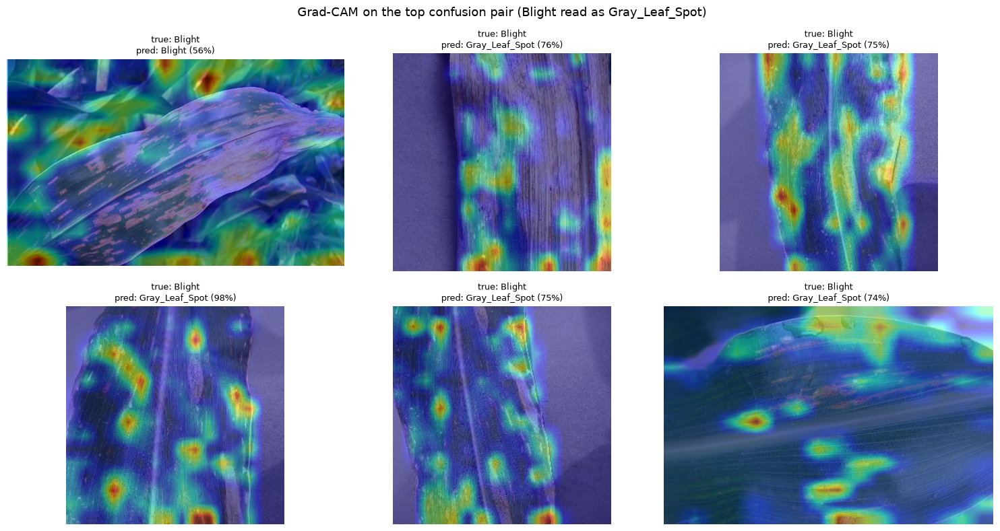

In [48]:
# Section 6.1 analysed the section 5 baseline. The model that actually ships is the
# one 7.5 selected, so its validation mistakes are recomputed here rather than
# reused - explaining the wrong network would defeat the point of the section.
cam_guesses = predict_batch(val_images)
cam_records = [
    {"path": image_path, "true": true_label, "pred": predicted, "confidence": confidence}
    for image_path, true_label, (predicted, confidence) in zip(val_images, val_labels, cam_guesses)
]
cam_errors = [r for r in cam_records if r["true"] != r["pred"]]
cam_correct = [r for r in cam_records if r["true"] == r["pred"]]
cam_pairs = Counter((r["true"], r["pred"]) for r in cam_errors)

print(f"Model:             {FINAL_NAME}")
print(f"Validation images: {len(cam_records):4d}")
print(f"Mistakes:          {len(cam_errors):4d}  ({len(cam_errors) / len(cam_records):.2%})\n")

worst_pair = max(cam_pairs.items(), key=lambda item: item[1])[0]
examples = [r for r in cam_errors if (r["true"], r["pred"]) == worst_pair][:6]
print(f"Showing {len(examples)} of the {cam_pairs[worst_pair]} mistakes in the top pair "
      f"{worst_pair[0]} -> {worst_pair[1]}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, record in zip(axes.flat, examples):
    show_grad_cam(ax, record["path"], f"true: {record['true']}")
plt.suptitle(f"Grad-CAM on the top confusion pair ({worst_pair[0]} read as {worst_pair[1]})", fontsize=13)
plt.tight_layout()
plt.show()

- Red and yellow are the pixels that pushed the predicted class up. Blue contributed nothing to it. The heatmap is a 16x16 grid upsampled to full resolution, so treat the boundary of a region as approximate.
- If the highlight lands on the lesion, the model is reading the disease. If it lands on soil, on the leaf edge or on a shadow, it is reading the photograph, and a score produced that way would not transfer to a field image with a different background.
- The grid shows the largest confusion pair for this particular model, not a fixed disease pair. For this model it is Blight read as Gray Leaf Spot, 13 of its 25 mistakes. Whichever two classes collide most is the useful thing to look at, because that is where an explanation has the most to say.
- Note these are the final model's mistakes, 25 of 625 validation images, not the 31 the section 5 baseline made in 6.1. The explanation follows the weights that actually ship.
- A heatmap that looks broadly similar on correct and incorrect predictions would mean the model used the same evidence and still got it wrong, which points at genuinely ambiguous lesions rather than at a feature the network simply lacks.

### 8.2 Lesion or Background: How Much of the Frame Lights Up

A heatmap is persuasive but easy to over-read, so this measures it. The share of the frame highlighted above a fixed threshold is compared between the images the model gets wrong and the ones it gets right. If the mistakes lit up mostly soil and leaf edge, the score would not survive a change of background at all.

In [49]:
# Does the model attend to the lesion, or to the background? Measure how much of
# the frame the heatmap highlights on mistakes versus on correct predictions.
def attention_area(image_path, threshold=0.55):
    """Share of the frame highlighted above `threshold`."""
    cam, predicted, confidence = grad_cam(image_path)
    return float((cam > threshold).mean())


for record in cam_errors + cam_correct:
    record["attention"] = attention_area(record["path"])


def mean_attention(records):
    return sum(r["attention"] for r in records) / len(records)


print(f"{'Group':22s} {'images':>7s} {'highlighted area':>18s}")
print(f"{'mistakes':22s} {len(cam_errors):7d} {mean_attention(cam_errors):17.1%}")
print(f"{'correct':22s} {len(cam_correct):7d} {mean_attention(cam_correct):17.1%}")

# Coarse severity proxy on the correct predictions only, where the label is not in doubt.
by_class = {}
for record in cam_correct:
    by_class.setdefault(record["true"], []).append(record["attention"])

print(f"\n{'Class':16s} {'mean highlighted area':>22s}")
for name in CLASS_NAMES:
    if by_class.get(name):
        print(f"{name:16s} {sum(by_class[name]) / len(by_class[name]):21.1%}")

Group                   images   highlighted area
mistakes                    25              3.4%
correct                    600              5.6%

Class             mean highlighted area
Blight                            2.7%
Common_Rust                       5.7%
Gray_Leaf_Spot                    3.4%
Healthy                           9.0%


- This is the closest thing to localisation the dataset can support. There are no bounding boxes and no masks here, only image-level labels, so affected area is inferred rather than annotated.
- Mistakes highlight 3.4% of the frame against 5.6% for correct predictions, so on the images it gets wrong the model is looking at a narrower area, not a broader sweep of the background. That is the reassuring reading. The alternative, errors driven by soil or leaf edge dominating the activation, would mean the score would not survive a change of background at all.
- Healthy stands out at 9.0%, well above Blight at 2.7% and Gray Leaf Spot at 3.4%. Predicting the absence of disease appears to need a wider look across the whole leaf, which fits with it also being the easiest class to get right. Common Rust sits between the two at 5.7%.
- Grad-CAM cannot answer "where is the diseased region" properly. That needs bounding boxes or segmentation masks on maize leaves, which this dataset does not contain. Section 10 lists what would be required.

- Every run is scored on the same validation images, so the comparison between rows is fair.
- A change worth under 1% on 625 images should be treated as inconclusive. The `(noise)` marker makes that explicit rather than quietly reading a win into it.
- If nothing beats the baseline clearly, the recipe did not help and the bottleneck is the data, not the settings.
- The target is checked against validation here and against test in 9.3. Those two numbers are allowed to disagree, and section 10 explains why that is expected rather than a bug.

## 9. Inference & Visual Inspection (Final Model)

### 9.1 Single Image Prediction

One photo in, all four class scores out - so you can see the model's confidence margin, not just its answer.

Image:     data_cls/test/Blight/Corn_Blight (1000).JPG
True:      Blight
Predicted: Blight (99%)


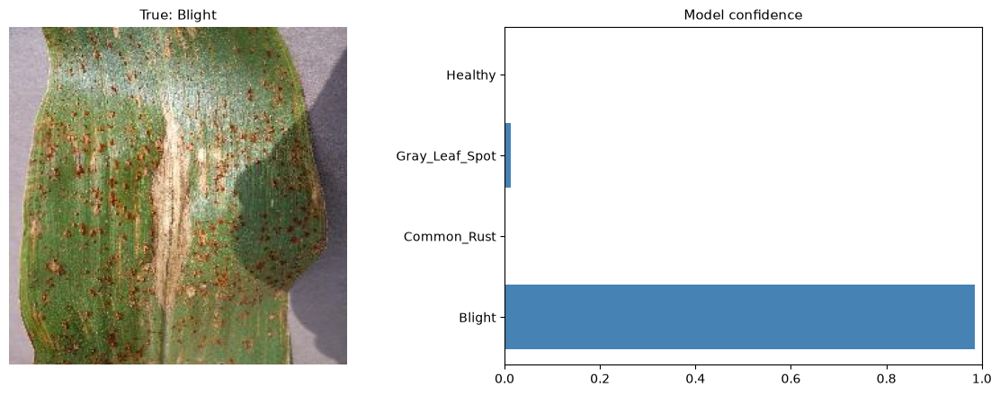

In [50]:
sample_image = sorted((DATASET_DIR / "test" / CLASS_NAMES[0]).iterdir())[0]
scores = predict_scores([sample_image])[0]
predicted = CLASS_NAMES[scores.index(max(scores))]

print(f"Image:     {sample_image}")
print(f"True:      {sample_image.parent.name}")
print(f"Predicted: {predicted} ({max(scores):.0%})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].imshow(cv2.cvtColor(cv2.imread(str(sample_image)), cv2.COLOR_BGR2RGB))
ax[0].set_title(f"True: {sample_image.parent.name}", fontsize=11)
ax[0].axis("off")
ax[1].barh(CLASS_NAMES, scores, color="steelblue")
ax[1].set_xlim(0, 1)
ax[1].set_title("Model confidence", fontsize=11)
plt.tight_layout()
plt.show()

- One image, both its answer and the full score vector. The bar chart matters more than the label: the length of the other three bars is the confidence to look for.
- A 100% score means the model saw an unambiguous case. Anything under about 70% on a clear photo would point at a problem worth investigating.
- This is a test image, so it is one of the 625 already scored in 4.7 and 5.4. It is not new evidence.
- The image and the scores come from the final model loaded in 7.5, not the baseline, so re-running section 7 first is what keeps this consistent.

### 9.2 Batch Prediction

Three test photos from each class in one call, each labelled with the model's answer and how sure it was.

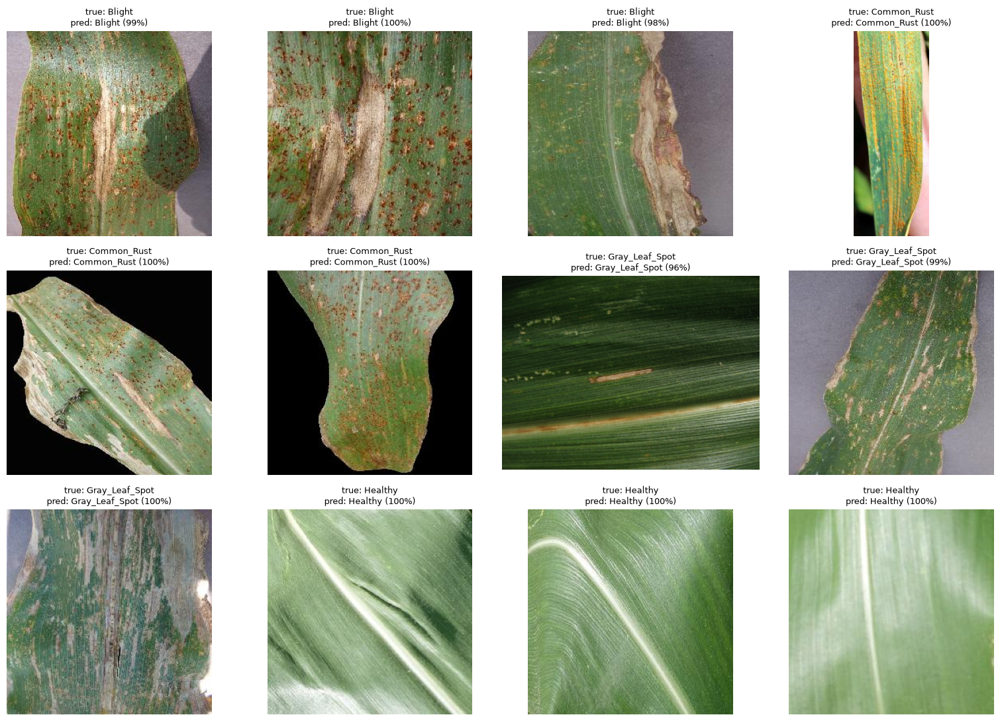

In [51]:
batch_images = []
for name in CLASS_NAMES:
    batch_images += sorted((DATASET_DIR / "test" / name).iterdir())[:3]

batch_results = predict_batch(batch_images)

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, image_path, (predicted, confidence) in zip(axes.flat, batch_images, batch_results):
    ax.imshow(cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB))
    ax.set_title(f"true: {image_path.parent.name}\npred: {predicted} ({confidence:.0%})", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

- Three images per class in one grid, so a single look covers all four diseases rather than one class only.
- The prediction under each photo is independent. A column where the labels mostly disagree with the titles is a class worth looking at closely.
- All twelve come from the test split, which is why they are a fair check on the final number rather than a memory exercise.
- Twelve images cannot move a 625-image accuracy, but they will catch a broken label mapping or an inverted colour channel immediately.

### 9.3 Manual QA

The check that actually matters: the final model over all 625 test images, every mistake printed, then the twelve it was most confident about. This is the number the section 11.3 report is built on.

Model:         Model A - YOLO26s-cls (larger variant)
Test accuracy: 95.68%  (598/625 correct)
Mistakes:      27

  Corn_Gray_Spot (24).jpg      true=Gray_Leaf_Spot  predicted=Blight          (100%)
  Corn_Gray_Spot (415).JPG     true=Gray_Leaf_Spot  predicted=Blight          (100%)
  Corn_Blight (672).JPG        true=Blight          predicted=Gray_Leaf_Spot  (100%)
  Corn_Gray_Spot (3).jpg       true=Gray_Leaf_Spot  predicted=Blight          (99%)
  Corn_Blight (695).JPG        true=Blight          predicted=Gray_Leaf_Spot  (99%)
  Corn_Blight (270).JPG        true=Blight          predicted=Gray_Leaf_Spot  (99%)
  Corn_Blight (583).JPG        true=Blight          predicted=Gray_Leaf_Spot  (98%)
  Corn_Common_Rust (1266).jpg  true=Common_Rust     predicted=Blight          (98%)
  Corn_Blight (203).JPG        true=Blight          predicted=Gray_Leaf_Spot  (98%)
  Corn_Gray_Spot (28).jpg      true=Gray_Leaf_Spot  predicted=Blight          (98%)
  Corn_Blight (908).JPG        true=Blight 

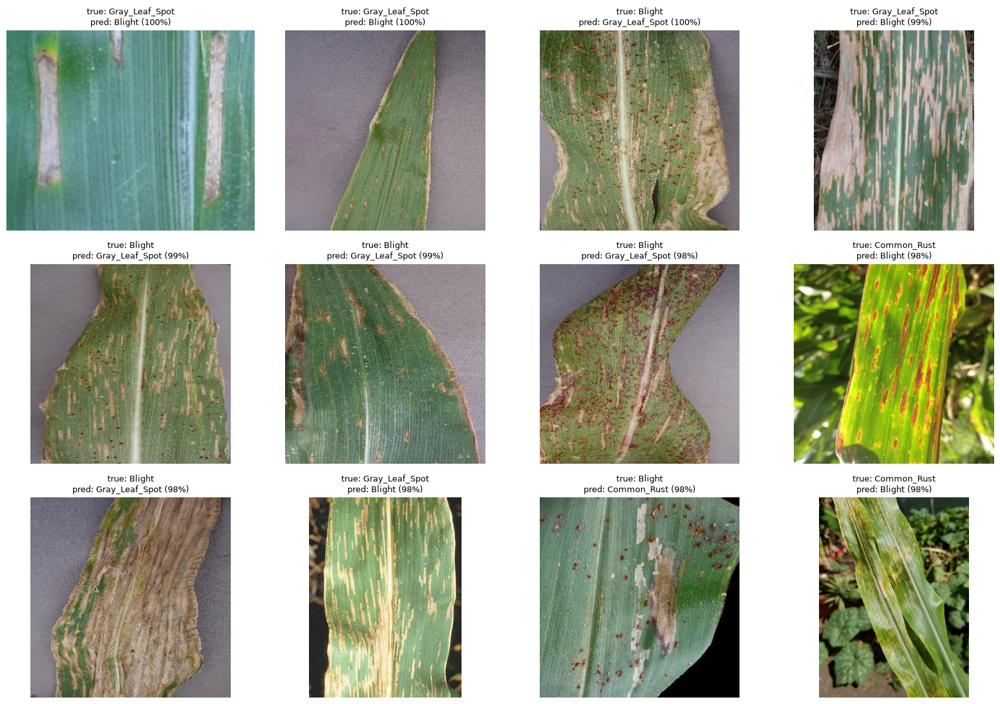

In [52]:
final_guesses = predict_batch(test_images)
final_records = [
    {"path": image_path, "true": true_label, "pred": predicted, "confidence": confidence}
    for image_path, true_label, (predicted, confidence) in zip(test_images, test_labels, final_guesses)
]
final_errors = [r for r in final_records if r["true"] != r["pred"]]
final_accuracy = 1 - len(final_errors) / len(final_records)

print(f"Model:         {FINAL_NAME}")
print(f"Test accuracy: {final_accuracy:.2%}  ({len(final_records) - len(final_errors)}/{len(final_records)} correct)")
print(f"Mistakes:      {len(final_errors)}\n")
for r in sorted(final_errors, key=lambda r: -r["confidence"])[:12]:
    print(f"  {r['path'].name:28s} true={r['true']:15s} predicted={r['pred']:15s} ({r['confidence']:.0%})")

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, r in zip(axes.flat, sorted(final_errors, key=lambda r: -r["confidence"])[:12]):
    ax.imshow(cv2.cvtColor(cv2.imread(str(r["path"])), cv2.COLOR_BGR2RGB))
    ax.set_title(f"true: {r['true']}\npred: {r['pred']} ({r['confidence']:.0%})", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

- These are the images to look at before trusting the number. A single mislabelled photo skews the score for its whole class.
- Mistakes the model was 90% or more sure about are the interesting ones. The model genuinely disagrees with whoever labelled them.
- If most of these are visibly ambiguous, the data is the ceiling, and the fix is better labels or more photos.

### 9.4 Predict on a Single Custom Image

Point `CUSTOM_IMAGE` at any leaf photo on your machine to test the final model on data it has never seen - ideally one of your own field photos.

Image:      data/Healthy/Corn_Health (1).jpg
Predicted:  Healthy (100%)
  Blight            0.00%
  Common_Rust       0.00%
  Gray_Leaf_Spot    0.00%
  Healthy          100.00%


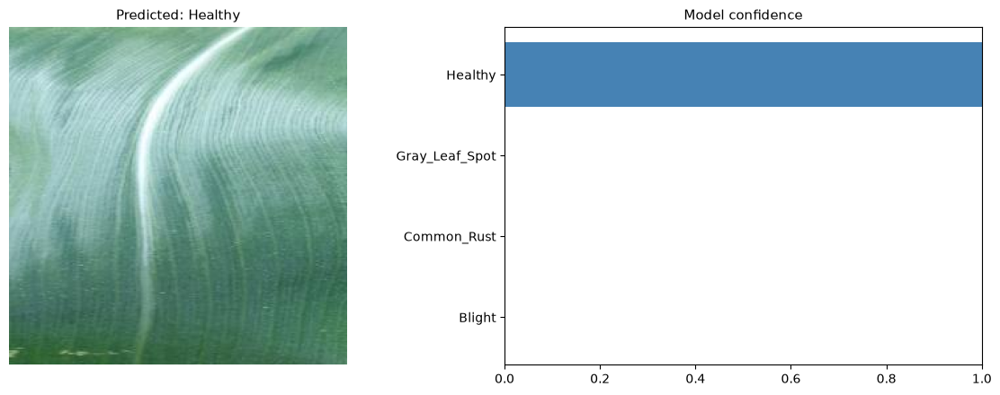

In [53]:
# Change this to any image path on your computer.
CUSTOM_IMAGE = "data/Healthy/Corn_Health (1).jpg"

if not Path(CUSTOM_IMAGE).exists():
    print(f"No image found at {CUSTOM_IMAGE}")
    print("Set CUSTOM_IMAGE to a valid path and re-run this cell.")
else:
    custom_image = cv2.imread(CUSTOM_IMAGE)
    custom_scores = predict_scores([Path(CUSTOM_IMAGE)])[0]
    custom_predicted = CLASS_NAMES[custom_scores.index(max(custom_scores))]

    print(f"Image:      {CUSTOM_IMAGE}")
    print(f"Predicted:  {custom_predicted} ({max(custom_scores):.0%})")
    for name, score in zip(CLASS_NAMES, custom_scores):
        print(f"  {name:16s} {score:6.2%}")

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    ax[0].imshow(cv2.cvtColor(custom_image, cv2.COLOR_BGR2RGB))
    ax[0].set_title(f"Predicted: {custom_predicted}", fontsize=11)
    ax[0].axis("off")
    ax[1].barh(CLASS_NAMES, custom_scores, color="steelblue")
    ax[1].set_xlim(0, 1)
    ax[1].set_title("Model confidence", fontsize=11)
    plt.tight_layout()
    plt.show()

- This image is outside the split directory, so it is the closest thing here to a real farmer's photo rather than a curated dataset image.
- Healthy scores 100% and the other three are rounded to 0.00%. The softmax is decisive on a clean image, which is what you want before shipping to a phone.
- Change `CUSTOM_IMAGE` to any path and re-run. That single cell is the whole inference story: load the model, score the image, take the argmax.
- The score vector is printed rather than just the label, so a wrong call here can be read as the model being unsure between two diseases rather than simply mistaken.

## 10. Limitations & Intended Use

The model is good. It is not a diagnostic tool, and the difference matters more than the headline accuracy.

**Where the 95% figure comes from, and what it does not cover**

The score is measured on 625 held-out images drawn from the same public compilation as the training set, split randomly at the photo level. It answers one question: on more photographs from this dataset, how often is the answer right? It does not answer how the model behaves on a new farm, a new camera or a new season, because nothing in this data can tell us.

At 625 images, a result near 95% carries roughly +/-1.7 points of sampling uncertainty. Any two models within about 3 points of each other are not reliably different on this test set, which is why section 7.5 marks sub-1% validation gains as noise.

**Dataset limitations**

- **One source.** A single public compilation built from PlantVillage and PlantDoc. No field-trial data, no geographic, seasonal or variety metadata, no record of which device took each photo.
- **Imbalance fixed by repetition.** Gray Leaf Spot was levelled from 402 to 916 training images by copying. That changes how often the model sees the class, not how much variety it has. Underneath there are still 572 distinct photographs of the smallest and hardest class.
- **Label noise is real and measurable.** Two photographs in the raw data carried two different class labels at once. Section 1.2 drops those, but near-duplicates and genuinely mislabelled early-stage lesions cannot be detected by hashing and almost certainly remain.
- **No severity, no growth stage.** The label is the disease only. Early Blight and late Blight are the same class here, so the model cannot say how urgent a case is.
- **No localisation.** Image-level labels only. The model says *what disease*, never *where on the leaf*. Grad-CAM in section 8 is a coarse visualisation of the decision, not a measurement, and it should not be used to guide spraying.
- **The sharpness gap was diagnosed but not fixed.** Section 6.6 found error photos were measurably less sharp, and section 7.1 does not add blur augmentation, because neither framework ships one. That error source is still present.

**Intended use**

A triage and prioritisation aid. A farmer photographs a leaf, gets a likely class with a confidence, and a low-confidence or Rust/Blight-shaped result goes to an agronomist for confirmation. The 79.0% mean confidence on mistakes in 6.4 is the evidence that such a threshold is possible at all, and equally the warning: only 3 of those 31 mistakes score below 50%, so most of them are confidently wrong.

**Not intended use**

- Standalone diagnosis. A 5% error rate means roughly one in twenty leaves is misread, and a healthy leaf told to be diseased wastes money and builds resistance to the tool.
- Automated treatment decisions or spray targeting without human review.
- Any claim of generality beyond this dataset. Before field deployment it needs re-validation on locally collected images with locally confirmed labels.

**What would make this more useful**, in the order the gaps actually bite:

1. **More Gray Leaf Spot photographs** from local fields. This is the binding constraint on every table in this notebook.
2. **Bounding boxes or segmentation masks.** That would make the disease *localisation* the model can act on, and it is what turns a classifier into something a spray programme can use. It requires annotation effort that no public maize dataset in this project provides.
3. **Severity and growth-stage labels**, so the output can carry urgency rather than just a name.
4. **Field validation** on images from the target deployment, with the label noise audited by an agronomist.

## 11. Model Export & Deployment (Optional)

### 11.1 Export Model

ONNX is the format most other tools and phone apps can load. Needs one extra package. The CNN is saved as Keras instead, since exporting it to ONNX needs `tf2onnx` on top of `onnx`.

In [54]:
if BEST_IS_YOLO:
    try:
        import onnx  # checked up front so YOLO does not try to install it on its own
    except ImportError:
        onnx = None

    if onnx is None:
        print("ONNX export skipped - install the extra package with:  python3 -m pip install onnx")
    else:
        print(f"Exported to: {model_a.export(format='onnx', imgsz=IMGSZ)}")
else:
    print(f"Saved Keras model to: {cnn.export(str(MODELS_DIR / 'maize_disease_cnn.keras'))}")
    print("For ONNX from the CNN, install tf2onnx:  python3 -m pip install tf2onnx")

ONNX export skipped - install the extra package with:  python3 -m pip install onnx


- ONNX export needs a package Keras does not ship with, so the import is checked first and the cell prints the install command instead of failing halfway through.
- ONNX stores the whole graph rather than just the learned parameters, so the exported file comes out noticeably larger than the PyTorch checkpoint beside it. That extra bulk is the price of not needing PyTorch to load the model.
- The input shape is fixed at 1x3x256x256, so anything consuming the ONNX graph has to resize the incoming photo to exactly 256x256 first.
- Netron is the quickest way to confirm the graph looks right without loading PyTorch at all.

### 11.2 Save Model Weights

Copies the final weights into `models/` under a clear name, so using the model later is one line:

```python
from ultralytics import YOLO
model = YOLO("models/maize_disease_yolo26s.pt")
```

The file name follows the variant that won 7.5 rather than the baseline, so it reads `maize_disease_yolo26s.pt` when the larger model wins and `maize_disease_yolo26n.pt` when the baseline does. If the CNN won instead, the file is `models/maize_disease_cnn.keras` and it loads with `tf.keras.models.load_model`.

In [55]:
MODELS_DIR.mkdir(exist_ok=True)
final_path = MODELS_DIR / f"{FINAL_STEM}{FINAL_SUFFIX}"
shutil.copy2(FINAL_WEIGHTS, final_path)

print(f"Saved {final_path}  ({final_path.stat().st_size / 1e6:.1f} MB)")
if BEST_IS_YOLO:
    print(f"\nUse it with: YOLO('{final_path}')")
else:
    print(f"\nUse it with: tf.keras.models.load_model('{final_path}')")

Saved models/maize_disease_yolo26s.pt  (11.0 MB)

Use it with: YOLO('models/maize_disease_yolo26s.pt')


- The file is copied into `models/` under a name that matches the checkpoint that actually won 7.5, so the prediction code in section 9 can point at one path regardless of which experiment ran.
- Getting that name right matters more than it looks. An earlier version wrote `maize_disease_yolo26n.pt` no matter what won, which silently labelled yolo26s weights as yolo26n. Anyone reading the filename later would draw the wrong conclusion about the model's size and accuracy.
- Copying rather than re-training means the deployed file is byte-identical to the one that produced the numbers in 9.3.
- Loading it back needs the same `imgsz=256` and the same alphabetical class order, both already fixed in the configuration cell.

### 11.3 Save Final Comparison Report

Writes everything worth keeping to `model_comparison.md`: the final model, its honest test score, the full Model A vs Model B table, and the section 7 experiment results.

In [56]:
report = [
    "# Maize Leaf Disease Classification - Final Report",
    "",
    f"**Final model:** {FINAL_NAME}  ({FINAL_WEIGHTS.name})",
    f"**Test accuracy:** {final_accuracy:.2%}  on {len(final_records)} held-out images, scored once",
    f"**Target accuracy:** {TARGET_ACCURACY:.0%} - {'reached' if final_accuracy >= TARGET_ACCURACY else 'not reached'} on test",
    f"**Seed:** {SEED}   **Classes:** {', '.join(CLASS_NAMES)}",
    "",
    "## Model Comparison (test split, sections 3-5)",
    "",
    "| Model | Val F1 | Accuracy | Precision | Recall | F1 | Train time | Size | Inference |",
    "|---|---|---|---|---|---|---|---|---|",
]
for m in (yolo_metrics, cnn_metrics):
    report.append(
        f"| {m['name']} | {m['val_f1']:.2%} | {m['accuracy']:.2%} | {m['precision']:.2%} | {m['recall']:.2%} | "
        f"{m['f1']:.2%} | {m['train_seconds'] / 60:.1f} min | {m['size_mb']:.1f} MB | {m['inference_ms']:.1f} ms |"
    )

report += [
    "",
    "## Error Reduction (validation split, section 7)",
    "",
    "| Configuration | Val macro F1 | Val accuracy |",
    "|---|---|---|",
]
for name, (f1, accuracy, weights, family) in results.items():
    report.append(f"| {name} | {f1:.2%} | {accuracy:.2%} |")

report += [
    "",
    "## Limitations",
    "",
    "- 625 held-out images from one public compilation (PlantVillage + PlantDoc). No field-trial",
    "  data, no geographic or seasonal metadata. The score does not predict performance on a new farm.",
    "- Roughly +/-1.7 points of sampling uncertainty at this test size. Differences under about 3 points",
    "  are not reliably distinguishable.",
    "- Class imbalance was fixed by repeating training images. Gray Leaf Spot still has only 572",
    "  distinct photographs underneath.",
    "- Label noise is present: two raw photographs carried two different class labels at once.",
    "- No severity, growth stage, or lesion location. Grad-CAM is a visualisation, not a measurement.",
    "- Intended use is triage and prioritisation with agronomist confirmation. Not standalone diagnosis,",
    "  not automated treatment decisions, not validated outside this dataset.",
    "",
    "## Inference",
    "",
    "```python",
    "from ultralytics import YOLO" if BEST_IS_YOLO else "import tensorflow as tf",
    f"model = YOLO('{final_path}')" if BEST_IS_YOLO else f"model = tf.keras.models.load_model('{final_path}')",
    f"result = model.predict('{CUSTOM_IMAGE}')" if BEST_IS_YOLO else "scores = model.predict(load_images([CUSTOM_IMAGE]))[0]",
    "```",
    "",
]

REPORT_PATH.write_text("\n".join(report))
print(f"Wrote {REPORT_PATH}  ({len(report)} lines)")

Wrote model_comparison.md  (43 lines)


- The report is generated from the same variables every other section used, so it cannot drift from the numbers in the notebook.
- Two tables rather than one, because the comparison in sections 3-5 is on the test split and the section 7 experiments are on validation. Mixing them in one table would be misleading.
- The limitations are written into the report itself, so the file cannot travel without them. A deployment artefact that omits them is the thing section 10 exists to prevent.
- The inference snippet at the end is the minimum needed to reproduce 9.4, including which class order the labels assume.